## 1. What this notebook computes

Two different computer programs solve the same Kohn-Sham equations of the fermion
field dirac16complex in the author's primordial gravitational field: the **Rust
solver** (whose results the previous chapter used) and an independent **Python
reference solver**, which shares no code with it and uses a different numerical
method. The **cross-check** compares the two, number by number, with a tolerance rule
that was fixed before any comparison was made. This notebook does that work itself
for a **subset** of five states:

- it runs the reference program of the repository on three ground states and two
  thermal states and checks that the new results reproduce the committed reference
  record;
- it shows how the reference results converge on its three grids, how **Richardson
  extrapolation** removes the grid error and measures what is left, and it tests that
  measured uncertainty on a fourth, finer grid;
- it builds the Rust solver, runs each state twice (with the **canonical** and with
  the **refined** numerics) and measures the Rust uncertainty from the difference;
- it applies the tolerance rule of the cross-check to 5140 comparisons (energies,
  levels, profiles, energy-momentum integrals, adiabaticity, thermodynamics) and
  reproduces the rows and the worst cases of the committed cross-check report;
- it draws seven figures: grid convergence, the fourth-grid test of the uncertainty,
  the convergence ratios of the levels, the agreement of the levels, the agreement
  of a density profile, the uncertainty budget, and all ratios of the subset by
  class.

Four of the five states were chosen because the full cross-check of all 210 states
found its largest differences in them; the fifth (N688_lam0_a00) has the largest
number of particles. The run takes two to six minutes on a fast computer (more
when other programs keep it busy) and about ten minutes on a typical laptop.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 16a (Running the reference solver on a subset and the cross-check) is the file
`Revision/textbook/notebooks/16a_reference_crosscheck.ipynb` of the repository
Dirac_claude. It runs the independent Python reference solver of the repository on five
Kohn-Sham states of dirac16complex in the deflating primordial field (three ground states
and two thermal states, four of them chosen because the full cross-check found its
largest differences there) and on a fourth, finer grid for one state, checks that every
new result reproduces the committed reference record, shows how the grids converge and
how Richardson extrapolation removes the grid error, builds the Rust solver and runs it
with its canonical and its refined numerics to measure its uncertainty, applies the
tolerance rule of the cross-check to 5140 comparisons, and reproduces the corresponding
rows and worst cases of the committed cross-check report. The raw outputs of the Rust
program go into a temporary folder of the operating system (outside the repository),
which the notebook deletes as soon as it has read them. It needs a computer with Windows
11, macOS or Linux, an internet connection for the installation, the program Git, and
Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy and matplotlib; the other packages run Jupyter,
the program that shows and runs notebooks. It also needs Rust (the program cargo, version
1.91.1 or newer), because it runs the Rust program revision_ks_solver, which is part of
the repository and is built on your computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/kohn_sham/solver/target/release/revision_ks_solver` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 16a_reference_crosscheck.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 16a_reference_crosscheck.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
16a_reference_crosscheck.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/16a.captions.json`
- `Revision/textbook/figures/16a_1_grid_convergence.png`
- `Revision/textbook/figures/16a_2_uncertainty_validated.png`
- `Revision/textbook/figures/16a_3_eigenvalue_ratios.png`
- `Revision/textbook/figures/16a_4_level_agreement.png`
- `Revision/textbook/figures/16a_5_profile_agreement.png`
- `Revision/textbook/figures/16a_6_uncertainty_budget.png`
- `Revision/textbook/figures/16a_7_ratios_by_class.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds; running it headless or saving it in JupyterLab also rewrites
the notebook file itself. It does not use the internet while it runs. The files it writes
are the same files that are stored in the repository (on another computer a figure may
differ in a few bytes, which is harmless). To get the stored versions back, run this
command in the repository folder (it also undoes every change you made yourself in the
folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 51 CHECKS PASSED (notebook 16a)

and the notebook must show 7 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/16a_reference_crosscheck.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.
- The cell that runs the reference solver on the three ground states shows the label with
  the star for a minute or longer: this is normal. The state N136_lamp2_a20 alone takes
  up to two minutes on a fast computer and up to five minutes on a laptop, because the
  reference solves 354 levels on three grids, each with its excited state and four
  neighbouring slices. Wait until the label shows a number.
- A line reports that a re-run is not identical byte for byte, but the PASS line after it
  appears: this is harmless. Another computer may round the last digit of a few numbers
  differently; the check allows differences of one part in a billion, far below every
  uncertainty of the record.
- An AssertionError names one of the comparisons with the record: the notebook prints the
  numbers just above the error. A large difference means that the reference program, the
  Rust solver or the record was changed. Get the stored versions back and run the
  notebook again.

      git checkout -- Revision/kohn_sham

- On Windows the cell that builds the Rust solver stops with the cargo message failed to
  remove file and Access is denied: the program revision_ks_solver is still running in
  another window or terminal, and Windows does not let cargo replace a running program.
  Wait until that run has finished (or close it), then run the cell again.
- The run was stopped (by an error, or with Kernel > Interrupt) while the cell that runs
  the Rust solver was busy: the raw outputs of the Rust runs may then be left behind in a
  folder whose name starts with textbook_16a_, inside the folder for temporary files of
  your operating system (in Python, tempfile.gettempdir() names it). The notebook deletes
  that folder only when the cell finishes. Delete the leftover folder by hand; every run
  makes a new one.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 16a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 16a (Running the reference solver on a subset and the cross-check) is the file
# Revision/textbook/notebooks/16a_reference_crosscheck.ipynb of the repository
# Dirac_claude. It runs the independent Python reference solver of the repository on five
# Kohn-Sham states of dirac16complex in the deflating primordial field (three ground
# states and two thermal states, four of them chosen because the full cross-check found
# its largest differences there) and on a fourth, finer grid for one state, checks that
# every new result reproduces the committed reference record, shows how the grids
# converge and how Richardson extrapolation removes the grid error, builds the Rust
# solver and runs it with its canonical and its refined numerics to measure its
# uncertainty, applies the tolerance rule of the cross-check to 5140 comparisons, and
# reproduces the corresponding rows and worst cases of the committed cross-check report.
# The raw outputs of the Rust program go into a temporary folder of the operating system
# (outside the repository), which the notebook deletes as soon as it has read them. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy and
# matplotlib; the other packages run Jupyter, the program that shows and runs notebooks.
# It also needs Rust (the program cargo, version 1.91.1 or newer), because it runs the
# Rust program revision_ks_solver, which is part of the repository and is built on your
# computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/kohn_sham/solver/target/release/revision_ks_solver (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 16a_reference_crosscheck.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 16a_reference_crosscheck.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 16a_reference_crosscheck.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/16a.captions.json
# - Revision/textbook/figures/16a_1_grid_convergence.png
# - Revision/textbook/figures/16a_2_uncertainty_validated.png
# - Revision/textbook/figures/16a_3_eigenvalue_ratios.png
# - Revision/textbook/figures/16a_4_level_agreement.png
# - Revision/textbook/figures/16a_5_profile_agreement.png
# - Revision/textbook/figures/16a_6_uncertainty_budget.png
# - Revision/textbook/figures/16a_7_ratios_by_class.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds; running it headless or saving it in JupyterLab also rewrites
# the notebook file itself. It does not use the internet while it runs. The files it
# writes are the same files that are stored in the repository (on another computer a
# figure may differ in a few bytes, which is harmless). To get the stored versions back,
# run this command in the repository folder (it also undoes every change you made
# yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 51 CHECKS PASSED (notebook 16a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/16a_reference_crosscheck.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
# - The cell that runs the reference solver on the three ground states shows the label
#   with the star for a minute or longer: this is normal. The state N136_lamp2_a20 alone
#   takes up to two minutes on a fast computer and up to five minutes on a laptop,
#   because the reference solves 354 levels on three grids, each with its excited state
#   and four neighbouring slices. Wait until the label shows a number.
# - A line reports that a re-run is not identical byte for byte, but the PASS line after
#   it appears: this is harmless. Another computer may round the last digit of a few
#   numbers differently; the check allows differences of one part in a billion, far below
#   every uncertainty of the record.
# - An AssertionError names one of the comparisons with the record: the notebook prints
#   the numbers just above the error. A large difference means that the reference
#   program, the Rust solver or the record was changed. Get the stored versions back and
#   run the notebook again.
#     git checkout -- Revision/kohn_sham
# - On Windows the cell that builds the Rust solver stops with the cargo message failed
#   to remove file and Access is denied: the program revision_ks_solver is still running
#   in another window or terminal, and Windows does not let cargo replace a running
#   program. Wait until that run has finished (or close it), then run the cell again.
# - The run was stopped (by an error, or with Kernel > Interrupt) while the cell that
#   runs the Rust solver was busy: the raw outputs of the Rust runs may then be left
#   behind in a folder whose name starts with textbook_16a_, inside the folder for
#   temporary files of your operating system (in Python, tempfile.gettempdir() names it).
#   The notebook deletes that folder only when the cell finishes. Delete the leftover
#   folder by hand; every run makes a new one.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "16a"  # this notebook: chapter 16, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 16a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Solver**: a program that computes the solution of equations. The **Rust solver**
  integrates the orbital equation step by step from one end of the hidden coordinate
  to the other (*shooting*). The **reference solver** writes the same equation as one
  large matrix on a grid and finds its eigenvalues.
- **Grid**: equally spaced points on the interval $-L \le y \le 0$. $G$ is the number
  of cells, $h = L/G$ the width of one cell. The reference uses $G = 300$, $600$ and
  $1200$; one state is also solved on $G = 2400$ (the **fourth grid**).
- **Grid error**: the difference between a number computed on a grid and the exact
  number. For the reference it shrinks like $h^2$.
- **Richardson extrapolation**: a combination of the results on several grids in
  which the leading grid errors cancel. $R$ is the extrapolated value, $U$ its
  measured **uncertainty** (how far it may still be from the exact value).
- **Validation**: a test of a stated uncertainty against a more accurate number.
- **Canonical numerics** of the Rust solver: $G = 900$ RK4 steps and its standard
  tolerances. **Refined numerics**: $G = 1800$ steps and ten times smaller
  tolerances. $U_{Rust}$ is the uncertainty of the canonical Rust result measured
  from the two.
- **Tolerance**: the largest difference allowed between the two solvers.
  **Ratio**: the difference divided by the tolerance; a comparison passes when the
  ratio is at most 1.
- **State id**: a name such as `N136_lamp2_a20`: $N = 136$ particles, coupling
  $+\lambda_2$ (`lam0`: $\lambda = 0$; `lamp1`, `lamm1`: $\pm\lambda_1$; `lamp2`,
  `lamm2`: $\pm\lambda_2$), slice $a_{4,0} = 2.0$ (the digits are ten times
  $a_{4,0}$). A thermal state ends with `_T10`, `_T20` or `_T50`: the temperature
  $T = 0.01$, $0.02$ or $0.05$ (in units of the mass $m$).
- **Level key** `n2:j:parity:rank`: the shell $n_2 = |\vec n|^2$ of the 3-space
  momentum, the block type $j = \pm 1$, the brane parity (even or odd), and the
  **rank**, the position of the level among the particle levels of its sector
  (0 = the lowest). The Rust solver numbers levels by a **label**; the rank is the
  label minus the label of the lowest particle level (`label_min`).
- **Profile**: a density as a function of $y$, stored at the 151 points
  $y = -3 + 0.02\,i$. **Brane value** and **tip value**: its values at $y = 0$ and
  $y = -3$.
- **JSON** and **CSV**: two text formats for stored numbers (JSON: named entries in
  braces; CSV: a table, one line per row, entries separated by commas).
- **Record**: a committed Revision file whose numbers this notebook reproduces.
  **Byte for byte identical**: two files that agree in every character.
- $E_{KS}$: the Kohn-Sham energy; $E_{band} = \sum g f \varepsilon$ the sum of the
  occupied levels; $E_{int}$ the interaction energy; $E_{KS} = E_{band} - E_{int}$.
  **HOMO**, **LUMO**: the highest occupied and lowest unoccupied level; the
  **KS gap** is their difference. **Delta-SCF**: the energy of the first excited
  state minus $E_{KS}$.
- $\int\rho$, $\int p_3$, $\int p_t$, $\int p_8$, $\int n$: the energy density, the
  three pressures and the particle density integrated over the hidden coordinate
  with the volume factor, $2\,\mathrm{Vol}_7 \int_{-L}^{0} e^{6Hy}(\dots)\,dy$.
- $dE/da_4$: how fast the energy changes along the history; $Q_{max}$: the
  **adiabaticity** measure (small means the slow-change approximation holds);
  $\Delta E_x$: the difference between the exact Fock exchange and the uniform-gas
  exchange.
- $\mu$, $E$, $S$, $F = E - TS$, $\Omega$: chemical potential, energy, entropy, free
  energy and grand potential of a thermal state; $C_V = T\,dS/dT$ its heat capacity.

## 4. The physical and mathematical situation

**The equations being solved.** The author's coordinates are $x_1, x_2, x_3$
(3-space, scale factor $e^{a_4} \sin^{1/6} z$), $x_4$ (the time), $x_5, x_6, x_7$
(the three extra times, which DEFLATE exponentially: scale factor
$e^{-a_4} \sin^{1/6} z$ with $a_4$ increasing) and $x_8$ (the hidden direction,
$z = 6Hx_8$, written through $y = \ln(\sin z)/(6H)$ in $-L \le y \le 0$). Along the
PRESCRIBED BACKGROUND history $a_4 = A H x_4$ ($A = 1$) the Kohn-Sham states are
computed at five instants, the **slices** $a_{4,0} = 0, 0.5, 1, 1.5, 2$. At a slice
each orbital $\chi(y)$ solves the $2\times 2$ block equation
$$h_j\,\chi = \varepsilon\,\chi, \qquad h_j = j\left[-i\sigma_1 \frac{d}{dy}
+ M\sigma_2 + \kappa k\,\sigma_3\right] + v, \qquad \kappa = e^{-Hy - a_{4,0}},$$
with the ASSUMED $Z_2$ brane at $y = 0$, a regular tip at $y = -L = -3$, and the
self-consistent potentials $M = m + \tfrac{15}{16}\lambda S$ and
$v = -\tfrac{1}{16}\lambda n$ (units $H = m = 1$).

**Two independent solvers.** The Rust solver shoots with RK4 ($G = 900$ steps); the
reference solver puts the two components of $\chi$ on a staggered grid, turns the
equation into a symmetric matrix of size $2G - 1$, and computes every quantity on
$G = 300$, $600$ and $1200$. Its error behaves like $c\,h^2 + d\,h^4 + \dots$, so the
Richardson value
$$R = \frac{64\,x(1200) - 20\,x(600) + x(300)}{45}$$
removes the $h^2$ and $h^4$ terms, and its uncertainty is
$U_{ref} = |R - (4\,x(1200) - x(600))/3| + 2\cdot 10^{-12}\max(1, |R|)$.

**The Rust uncertainty.** RK4 has errors of order $h^4$. Halving the step divides
the error $e$ by $2^4 = 16$, so canonical minus refined is $e - e/16 = \tfrac{15}{16}e$
and the canonical error is $e = \tfrac{16}{15}\,|x_{canonical} - x_{refined}|$. This
is $U_{Rust}$.

**The tolerance rule** (fixed in the cross-check program before any comparison):
$$|x_{Rust} - x_{ref}| \le 3\,(U_{ref} + U_{Rust}) + 10^{-12}\cdot\text{scale},$$
with scale $= \max(1, |x|)$ for single numbers and the largest value of the profile
for profile points. The **ratio** is the left side divided by the right side.

**The subset.** The committed cross-check compared all 210 states (75 ground, 135
thermal) and passed all 31 checks. This notebook recomputes five of them:

| state | $N$ | $\lambda$ | $a_{4,0}$ | $T$ | why it is in the subset |
| --- | --- | --- | --- | --- | --- |
| N8_lamm2_a00 | 8 | $-\lambda_2$ | 0 | 0 | largest ratio of all, at the tip |
| N688_lam0_a00 | 688 | 0 | 0 | 0 | the largest number of particles |
| N136_lamp2_a20 | 136 | $+\lambda_2$ | 2 | 0 | largest ratios of levels and $Q_{max}$ |
| N8_lamm1_a00_T10 | 8 | $-\lambda_1$ | 0 | 0.01 | where the first cross-check failed |
| N8_lam0_a15_T50 | 8 | 0 | 1.5 | 0.05 | largest thermal ratios |

The values of $\lambda_1$ and $\lambda_2$ depend on $N$; the next cells read them.
What the cross-check can and cannot show is said at the end of the notebook.

## 5. The records and the problem definition of both solvers

The next cell reads the three committed reports (reference, Rust solver,
cross-check) and checks that every check in them passed. Then it compares the
problem definitions in the two `parameters.json` files (the physical constants
$H$, $m$, $L$, $\Delta k$, $v_t$, the tip angle, the history, the slices, the
temperatures, and the fingerprint of the theory file both programs read) and the
six couplings that each solver derived on its own from the same rule. This repeats
the cross-check's checks `problem_definition_identical` and (for the couplings)
`parameters_couplings`. It also prints the sizes of the two checks that the
cross-check gained on 2026-10-08: `thermo_levels` (every level of every thermal
state, label by label) and `thermo_mu_rust_stated_bound` (the Rust solver's stated
rounding bound of $\mu$, tested against roots computed with 40 digits).

In [2]:
import csv  # reads tables stored as CSV files (comma-separated values)
import re  # finds patterns in text (used to read numbers out of report sentences)
import sys  # the list of folders in which Python looks for modules
import tempfile  # makes temporary folders outside the repository

import numpy as np  # arrays of numbers

KS = "Revision/kohn_sham"  # the folder of the Kohn-Sham record (repository path)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def read_csv(relative):
    """Read a CSV file of the repository: a list of rows, each row a dictionary from
    the column names to the texts in that row."""
    with open(repository_file(relative), newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


REPORTS = {"reference solver": read_json(f"{KS}/reports/ks-reference.json"),
           "Rust solver": read_json(f"{KS}/reports/ks-rust-solver.json"),
           "cross-check": read_json(f"{KS}/reports/ks-crosscheck.json")}
counts = {}
for label, rep in REPORTS.items():
    summary = rep["summary"]  # {"checks": ..., "pass": ..., "fail": ...}
    counts[label] = (summary["pass"], summary["checks"])
    say(f"{label}: {summary['pass']} of {summary['checks']} checks PASS")
check(counts == {"reference solver": (37, 37), "Rust solver": (42, 42),
                 "cross-check": (31, 31)},
      "the three committed reports pass every check (37, 42 and 31)")
CROSS = {c["name"]: c for c in REPORTS["cross-check"]["checks"]}  # name -> check
for name in ["thermo_levels", "thermo_mu_rust_stated_bound"]:  # the two newest
    detail = CROSS[name]["detail"]  # the report's sentence about this check
    size = re.search(r"(\d+) comparisons", detail).group(1)  # a number in the text
    say(f"cross-check {name}: {size} comparisons, verdict {CROSS[name]['verdict']}")

RUST_PARAMS = read_json(f"{KS}/results/parameters.json")  # the Rust solver's
REF_PARAMS = read_json(f"{KS}/reference/results/parameters.json")  # the reference's
pairs = [("H", "H"), ("m", "m"), ("L_tipCutoff", "L"), ("dk", "dk"), ("v_t", "vt"),
         ("tipTheta", "tipTheta"), ("historyA", "historyA"),
         ("slicesA4", "slicesA4"), ("temperatures", "temperatures")]
differ = [rust_name for rust_name, ref_name in pairs
          if RUST_PARAMS["physics"][rust_name] != REF_PARAMS["physics"][ref_name]]
same_theory = (RUST_PARAMS["theoryInputs"]["ksTheorySha256"]
               == REF_PARAMS["theoryInputs"]["ksTheorySha256"])
for rust_name, ref_name in pairs:
    say(f"  {rust_name:13s} Rust {RUST_PARAMS['physics'][rust_name]}   reference "
        f"{REF_PARAMS['physics'][ref_name]}")
check(not differ and same_theory,
      "both solvers solve the same problem and read the same ks-theory.json",
      record=f"{KS}/reports/ks-crosscheck.json, check problem_definition_identical")

LAMBDAS = {}  # N -> {"lamp1": +lambda_1, ...}: the couplings of the reference
rust_cal = {c["N"]: c for c in RUST_PARAMS["couplingCalibration"]["values"]}
same_couplings = True
for cal in REF_PARAMS["derived"]["calibration"]:
    N = cal["N"]
    LAMBDAS[N] = {"lam0": 0.0, "lamp1": cal["lambda1"], "lamm1": -cal["lambda1"],
                  "lamp2": cal["lambda2"], "lamm2": -cal["lambda2"]}
    same_couplings &= (cal["lambda1"] == rust_cal[N]["lambda1"]
                       and cal["lambda2"] == rust_cal[N]["lambda2"])
    say(f"N = {N:5.0f}: lambda_1 = {cal['lambda1']}, lambda_2 = {cal['lambda2']}")
check(same_couplings, "the six couplings derived by the two solvers are identical",
      record=f"{KS}/reports/ks-crosscheck.json, check parameters_couplings")

reference solver: 37 of 37 checks PASS
Rust solver: 42 of 42 checks PASS
cross-check: 31 of 31 checks PASS
PASS the three committed reports pass every check (37, 42 and 31)
cross-check thermo_levels: 34378 comparisons, verdict PASS
cross-check thermo_mu_rust_stated_bound: 270 comparisons, verdict PASS
  H             Rust 1.0   reference 1.0
  m             Rust 1.0   reference 1.0
  L_tipCutoff   Rust 3.0   reference 3.0
  dk            Rust 0.25   reference 0.25
  v_t           Rust 1.0   reference 1.0
  tipTheta      Rust 0.0   reference 0.0
  historyA      Rust 1.0   reference 1.0
  slicesA4      Rust [0.0, 0.5, 1.0, 1.5, 2.0]   reference [0.0, 0.5, 1.0, 1.5, 2.0]
  temperatures  Rust [0.01, 0.02, 0.05]   reference [0.01, 0.02, 0.05]
PASS both solvers solve the same problem and read the same ks-theory.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    problem_definition_identical
N =     8: lambda_1 = 0.01946, lambda_2 = 0.05838
N =   136: lambda_1 = 0.00

## 6. The reference program and the five states

The reference program is the Python file `Revision/kohn_sham/reference/run_reference.py`
(it uses `ks_fd.py` in the same folder). Its **jobs** compute one state each: a
ground-state job solves the state, its Delta-SCF excited state, four neighbouring
slices $a_{4,0} \pm 0.002$, $\pm 0.004$ (for $dE/da_4$ and the adiabaticity
measure) and its particle-hole list, all on the three grids; a thermal job solves the
state and four neighbouring temperatures $T(1 \pm 0.01)$, $T(1 \pm 0.02)$ (for
$C_V$). The next cell makes Python find the program, imports it **without running
it** (importing only defines its functions), reads the functional coefficients it
takes from `ks-theory.json`, and writes down the five states as the program's job
descriptions: the id, $N$, the coupling tag and value, the slice, the first-order
mean-field size $\sigma$ (0, 0.1 or 0.3; it sets how many levels are kept), and the
temperature.

In [3]:
sys.dont_write_bytecode = True  # do not write a __pycache__ folder into the record
sys.path.insert(0, str(repository_file(f"{KS}/reference")))  # Python looks here too
import run_reference as RR  # noqa: E402  the reference program (Revision code)

CO = RR.theory_coefficients()  # coefficients read and checked from ks-theory.json
say(f"functional coefficients: M_eff = m + {CO['cM']} lambda S, "
    f"v_v = {CO['cV']} lambda n, e_int = lambda ({CO['eS2']} S^2 + {CO['eN2']} n^2)")


def job_spec(N, tag, a4, T=None):
    """The reference program's description of one state (a dictionary)."""
    spec = {"id": RR.run_id(N, tag, a4, T), "N": N, "tag": tag,
            "lam": LAMBDAS[N][tag], "a4": a4, "sigma": RR.SIGMA[tag]}
    if T is not None:
        spec["T"] = T
    return spec


SPECS = {}
for args in [(8.0, "lamm2", 0.0), (688.0, "lam0", 0.0), (136.0, "lamp2", 2.0),
             (8.0, "lamm1", 0.0, 0.01), (8.0, "lam0", 1.5, 0.05)]:
    spec = job_spec(*args)
    SPECS[spec["id"]] = spec
GROUND_IDS = ["N8_lamm2_a00", "N688_lam0_a00", "N136_lamp2_a20"]
THERMAL_IDS = ["N8_lamm1_a00_T10", "N8_lam0_a15_T50"]
print("state               N   lambda       a4,0  sigma  T")
for sid, spec in SPECS.items():
    print(f"{sid:18s} {spec['N']:4.0f}  {spec['lam']:+.5f}  {spec['a4']:4.1f}  "
          f"{spec['sigma']:4.1f}   {spec.get('T', 0.0):.2f}")
check(sorted(SPECS) == sorted(GROUND_IDS + THERMAL_IDS),
      "the five job descriptions have the ids of the subset")

functional coefficients: M_eff = m + 15/16 lambda S, v_v = -1/16 lambda n, e_int = lambda
    (15/32 S^2 + -1/32 n^2)
state               N   lambda       a4,0  sigma  T
N8_lamm2_a00          8  -0.05838   0.0   0.3   0.00
N688_lam0_a00       688  +0.00000   0.0   0.0   0.00
N136_lamp2_a20      136  +0.00279   2.0   0.3   0.00
N8_lamm1_a00_T10      8  -0.01946   0.0   0.1   0.01
N8_lam0_a15_T50       8  +0.00000   1.5   0.0   0.05
PASS the five job descriptions have the ids of the subset


## 7. Running the reference solver on the three ground states

The next cell runs the reference program's ground-state job for each of the three
ground states. One addition: the job calls the program's function `_ground_on_grid`
once for each grid and keeps only the extrapolated levels. To draw the convergence
of every level we want the levels on each grid as well, so the cell **wraps** that
function: it puts in its place a small function of our own that calls the original
one, keeps a copy of the levels it returns, and passes its result on unchanged. After
the three jobs the original function is put back. The results are the contents of
the JSON files the reference program writes (`RR.jsonable` turns the arrays into
plain numbers, as the program does before it writes a file). This cell takes one
to three minutes on a fast computer.

In [4]:
PER_GRID = {}  # (state id, G) -> the levels of the state on grid G (an array)
original_ground_on_grid = RR._ground_on_grid  # the reference's function for one grid


def ground_on_grid_recorded(co, spec, G, labels):
    """Call the reference's own function for one grid and keep a copy of its levels."""
    result = original_ground_on_grid(co, spec, G, labels)
    PER_GRID[(spec["id"], G)] = result["eps"].copy()
    return result


RR._ground_on_grid = ground_on_grid_recorded  # the job now calls our wrapper
NEW = {}  # state id -> the new reference result (the content of its JSON file)
for sid in GROUND_IDS:
    NEW[sid] = RR.jsonable(RR.ground_job(CO, SPECS[sid])["data"])
    E = NEW[sid]["scalars"]["E_KS"]
    say(f"{sid}: {NEW[sid]['levels_in_set']} levels, E_KS = {E['value']:.13f} "
        f"(U = {E['U']:.1e})")
RR._ground_on_grid = original_ground_on_grid  # put the original function back
check(len(PER_GRID) == 9, "the levels of three states on three grids were kept")

N8_lamm2_a00: 22 levels, E_KS = 0.0028626521737 (U = 2.1e-12)
N688_lam0_a00: 137 levels, E_KS = 680.4412465815219 (U = 3.3e-09)
N136_lamp2_a20: 354 levels, E_KS = 12.4489994812532 (U = 4.6e-11)
PASS the levels of three states on three grids were kept


The next cell compares each new result with the committed file
`Revision/kohn_sham/reference/results/ground/<id>.json`. The function
`compare_records` walks through both structures at the same time: the same names in
every dictionary, the same length of every list, the same texts and truth values,
and every number equal within one part in a billion ($10^{-9}$ relative). It counts
the numbers it compared. The function `check_reproduction` also writes the new
result as text exactly as the reference program writes its files and reports
whether that text is identical to the committed file **byte for byte** (on the
computer that built this book it is; the cross-check's own repeat run found the
same for all 340 files).

In [5]:
def compare_records(new, old, problems, where="top"):
    """Compare two JSON structures; return the number of numbers compared and append
    a description of every difference to the list problems."""
    if isinstance(new, bool) or isinstance(old, bool) or new is None or \
            isinstance(new, str):
        if new != old:
            problems.append(f"{where}: {new!r} != {old!r}")
        return 0
    if isinstance(new, (int, float)):
        if not isinstance(old, (int, float)) or \
                abs(new - old) > 1e-9 * max(1.0, abs(old)):
            problems.append(f"{where}: {new!r} != {old!r}")
        return 1
    if isinstance(new, dict):
        if sorted(new) != sorted(old):
            problems.append(f"{where}: different names")
            return 0
        return sum(compare_records(new[k], old[k], problems, f"{where}/{k}")
                   for k in new)
    if len(new) != len(old):  # a list
        problems.append(f"{where}: lengths {len(new)} and {len(old)}")
        return 0
    return sum(compare_records(a, b, problems, f"{where}[{i}]")
               for i, (a, b) in enumerate(zip(new, old)))


def check_reproduction(label, data, relative):
    """Check the new result data (named label) against its committed file."""
    committed = repository_file(relative).read_text(encoding="utf-8")
    problems = []
    numbers = compare_records(data, json.loads(committed), problems)
    text = json.dumps(data, indent=1, ensure_ascii=True) + "\n"  # as written
    say(f"{label}: {numbers} numbers compared; identical byte for byte: "
        f"{text == committed}")
    for line in problems[:5]:  # the first differences, if there are any
        say(f"  difference {line}")
    check(not problems,
          f"the re-run of {label} reproduces {relative.split('/results/')[1]}",
          record=f"{KS}/reports/ks-crosscheck.json, check "
                 "reference_repeat_byte_identical")


for sid in GROUND_IDS:
    check_reproduction(sid, NEW[sid], f"{KS}/reference/results/ground/{sid}.json")

N8_lamm2_a00: 3597 numbers compared; identical byte for byte: True
PASS the re-run of N8_lamm2_a00 reproduces ground/N8_lamm2_a00.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_byte_identical
N688_lam0_a00: 4513 numbers compared; identical byte for byte: True
PASS the re-run of N688_lam0_a00 reproduces ground/N688_lam0_a00.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_byte_identical
N136_lamp2_a20: 5815 numbers compared; identical byte for byte: True
PASS the re-run of N136_lamp2_a20 reproduces ground/N136_lamp2_a20.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_byte_identical


## 8. Richardson extrapolation at work

Write $x(h)$ for a number computed on a grid with cell width $h$ and $X$ for its exact
value. For the staggered grid the error has only even powers of $h$:
$$x(h) = X + c\,h^2 + d\,h^4 + \dots$$
The three grids have $h$, $h/2$ and $h/4$ ($G = 300$, $600$, $1200$). Line by line:

- Halving $h$ gives $x(h/2) = X + c\,h^2/4 + d\,h^4/16 + \dots$ (put $h/2$ in place of
  $h$).
- Then $4\,x(h/2) - x(h) = 3X + (4/16 - 1)\,d\,h^4 + \dots$ (the $c\,h^2$ terms cancel,
  because $4 \cdot c h^2/4 = c h^2$).
- So $r(h) = \frac{4\,x(h/2) - x(h)}{3} = X - \frac{d\,h^4}{4} + \dots$: one
  Richardson step leaves an $h^4$ error.
- The same step on the finer pair gives $r(h/2) = X - \frac{d\,h^4}{64} + \dots$.
- Then $\frac{16\,r(h/2) - r(h)}{15} = X + \dots$ (the $h^4$ terms cancel, because
  $16/64 = 1/4$), and multiplying out gives
  $R = \frac{64\,x(h/4) - 20\,x(h/2) + x(h)}{45}$.
- The leftover error of the finest one-step value $r(h/2)$ is about $|R - r(h/2)|$;
  that is the uncertainty $U$ (plus a floor $2\cdot 10^{-12}\max(1,|R|)$ for
  rounding). Because $R$ has removed one more error term than $r(h/2)$, $U$ is meant
  to over-estimate the error of $R$; section 9 tests this on a fourth grid.
- Because $x(h) - x(h/2) \approx \tfrac34 c h^2$ and
  $x(h/2) - x(h/4) \approx \tfrac{3}{16} c h^2$, their **ratio is 4** when the grids
  are fine enough for the $h^2$ term to dominate (the *asymptotic regime*).

The next cell prints $E_{KS}$ of each ground state on the three grids, computes $R$
and $U$ with our own lines (both written forms of $R$), checks that they equal the
values in the reference result, and prints the ratio of the differences.

In [6]:
def richardson(x1, x2, x3):
    """Three-grid Richardson value R and its uncertainty U (x1 on the coarsest grid),
    in the two-step form of the reference program; also the two one-step values."""
    r_fine = (4.0 * x3 - x2) / 3.0  # one step on the grids h/2 and h/4
    r_coarse = (4.0 * x2 - x1) / 3.0  # one step on the grids h and h/2
    R = (16.0 * r_fine - r_coarse) / 15.0  # the second step
    U = abs(R - r_fine) + 2e-12 * max(1.0, abs(R))
    return R, U, r_coarse, r_fine


CONVERGENCE = {}  # state id -> (E_KS on the three grids, R)
for sid in GROUND_IDS:
    xs = [grid["scalars"]["E_KS"] for grid in NEW[sid]["per_grid"]]
    R, U, _, _ = richardson(*xs)
    R_one_line = (64.0 * xs[2] - 20.0 * xs[1] + xs[0]) / 45.0
    stored = NEW[sid]["scalars"]["E_KS"]
    ratio = (xs[0] - xs[1]) / (xs[1] - xs[2])
    CONVERGENCE[sid] = (xs, R)
    say(f"{sid}: E_KS(300) = {xs[0]:.12f}, E_KS(600) = {xs[1]:.12f}, "
        f"E_KS(1200) = {xs[2]:.12f}")
    say(f"    R = {R:.13f}, U = {U:.1e}, ratio of the differences = {ratio:.5f}")
    check(abs(R - stored["value"]) <= 1e-14 * max(1.0, abs(R))
          and abs(U - stored["U"]) <= 1e-14 * max(1.0, abs(R))
          and abs(R_one_line - R) <= 1e-13 * max(1.0, abs(R)),
          f"our Richardson lines give the reference value and U of E_KS ({sid})")

N8_lamm2_a00: E_KS(300) = 0.002862539189, E_KS(600) = 0.002862623929, E_KS(1200) =
    0.002862645113
    R = 0.0028626521737, U = 2.1e-12, ratio of the differences = 4.00020
PASS our Richardson lines give the reference value and U of E_KS (N8_lamm2_a00)
N688_lam0_a00: E_KS(300) = 680.448036126842, E_KS(600) = 680.442943944824, E_KS(1200) =
    680.441670920908
    R = 680.4412465815219, U = 3.3e-09, ratio of the differences = 4.00007
PASS our Richardson lines give the reference value and U of E_KS (N688_lam0_a00)
N136_lamp2_a20: E_KS(300) = 12.449082943357, E_KS(600) = 12.449020346521, E_KS(1200) =
    12.449004697554
    R = 12.4489994812532, U = 4.6e-11, ratio of the differences = 4.00006
PASS our Richardson lines give the reference value and U of E_KS (N136_lamp2_a20)


## 9. A fourth grid tests the uncertainty

Is $U$ really larger than the error of $R$? The reference program answers this with
its job `validation_job`: it solves one state, N136_lamp2_a20 (the strongest coupling
with the largest densities at the tip), on four grids $G = 300, 600, 1200, 2400$,
forms the three-grid value twice, $R_{123}$ from $(300, 600, 1200)$ and $R_{234}$
from $(600, 1200, 2400)$, and compares $|R_{123} - R_{234}|$ with the stated
uncertainty $U_{123}$ for 19 classes of quantities (energies, HOMO, LUMO, integrals,
tip and brane values, all levels, five profiles). $R_{234}$ is much closer to the
exact value than $R_{123}$ (its grids are twice as fine and its leftover error
shrinks like $h^6$), so $|R_{123} - R_{234}|$ is practically the error of $R_{123}$.

The next cell runs that job again (about 40 seconds) and compares its result with the
committed file `Revision/kohn_sham/reference/results/validation/N136_lamp2_a20.json`.
To draw the four grids we again use a wrapper: the job calls the function
`observables` of `ks_fd` once on each grid, and our wrapper keeps $E_{KS}$, the
levels and the tip value of $p_8$ of each grid.

In [7]:
FOUR_GRIDS = {}  # G -> (E_KS, levels, p8 at the tip) of N136_lamp2_a20 on grid G
original_observables = RR.K.observables  # the function of ks_fd (RR.K is ks_fd)


def observables_recorded(state):
    """Call ks_fd's own function and keep E_KS, the levels and p8 at the tip."""
    scalars, profiles = original_observables(state)
    FOUR_GRIDS[state.grid.G] = (scalars["E_KS"], state.eps.copy(),
                                scalars["p8_tip"])
    return scalars, profiles


RR.K.observables = observables_recorded  # the job now calls our wrapper
VALIDATION = RR.jsonable(RR.validation_job(CO, SPECS["N136_lamp2_a20"])["data"])
RR.K.observables = original_observables  # put the original function back
check_reproduction("the fourth-grid validation", VALIDATION,
                   f"{KS}/reference/results/validation/N136_lamp2_a20.json")
same = all(abs(FOUR_GRIDS[G][0] - grid["scalars"]["E_KS"]) <= 1e-12
           for G, grid in zip((300, 600, 1200), NEW["N136_lamp2_a20"]["per_grid"]))
check(sorted(FOUR_GRIDS) == [300, 600, 1200, 2400] and same,
      "the validation run repeats the ground job's E_KS on the three common grids")
classes = VALIDATION["classes"]
for name, c in classes.items():
    say(f"  {name:20s} {c['elements']:4d} element(s): max |R123 - R234| / U123 = "
        f"{c['max_ratio_to_U123']:.2e}")
worst = max(classes, key=lambda name: classes[name]["max_ratio_to_U123"])
detail = next(c["detail"] for c in REPORTS["reference solver"]["checks"]
              if c["name"] == "richardson_uncertainty_validated")
stated = float(re.search(r"U123 = ([0-9.]+) \((\w+)\)", detail).group(1))
say(f"largest ratio {classes[worst]['max_ratio_to_U123']:.3f} ({worst}); "
    f"the report states {stated}")
check(all(c["all_within_U123"] for c in classes.values())
      and len(classes) == 19 and worst == "p8_tip"
      and abs(classes[worst]["max_ratio_to_U123"] - stated) <= 5e-4,
      "on the fourth grid every three-grid value moves by less than its U",
      record=f"{KS}/reports/ks-reference.json, check richardson_uncertainty_validated")

the fourth-grid validation: 99 numbers compared; identical byte for byte: True
PASS the re-run of the fourth-grid validation reproduces validation/N136_lamp2_a20.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_byte_identical
PASS the validation run repeats the ground job's E_KS on the three common grids
  E_KS                    1 element(s): max |R123 - R234| / U123 = 7.66e-04
  E_int                   1 element(s): max |R123 - R234| / U123 = 1.02e-03
  HOMO                    1 element(s): max |R123 - R234| / U123 = 1.22e-04
  LUMO                    1 element(s): max |R123 - R234| / U123 = 2.40e-04
  int_rho                 1 element(s): max |R123 - R234| / U123 = 5.73e-04
  int_p3                  1 element(s): max |R123 - R234| / U123 = 0.00e+00
  int_p8                  1 element(s): max |R123 - R234| / U123 = 2.04e-03
  dE_da4_emt              1 element(s): max |R123 - R234| / U123 = 1.46e-04
  deltaE_x_exact_fock     1 element(s): 

The next figure shows convergence as a picture. Left: for the three ground states, the
distance $|x(G) - R|$ of $E_{KS}$ on each grid from the extrapolated value, against
the cell width $h = 3/G$, on logarithmic axes; a straight line of slope 2 means an
error proportional to $h^2$. Right: N136_lamp2_a20 on all four grids, every distance
measured from the best value $R_{234}$: the single grids (slope 2), the three
one-step values $r$ from neighbouring pairs of grids (slope 4), and the three-grid
value $R_{123}$ next to its stated uncertainty $U_{123}$. The dashed guide lines
have slopes 2 and 4 and pass through the first point of their series.

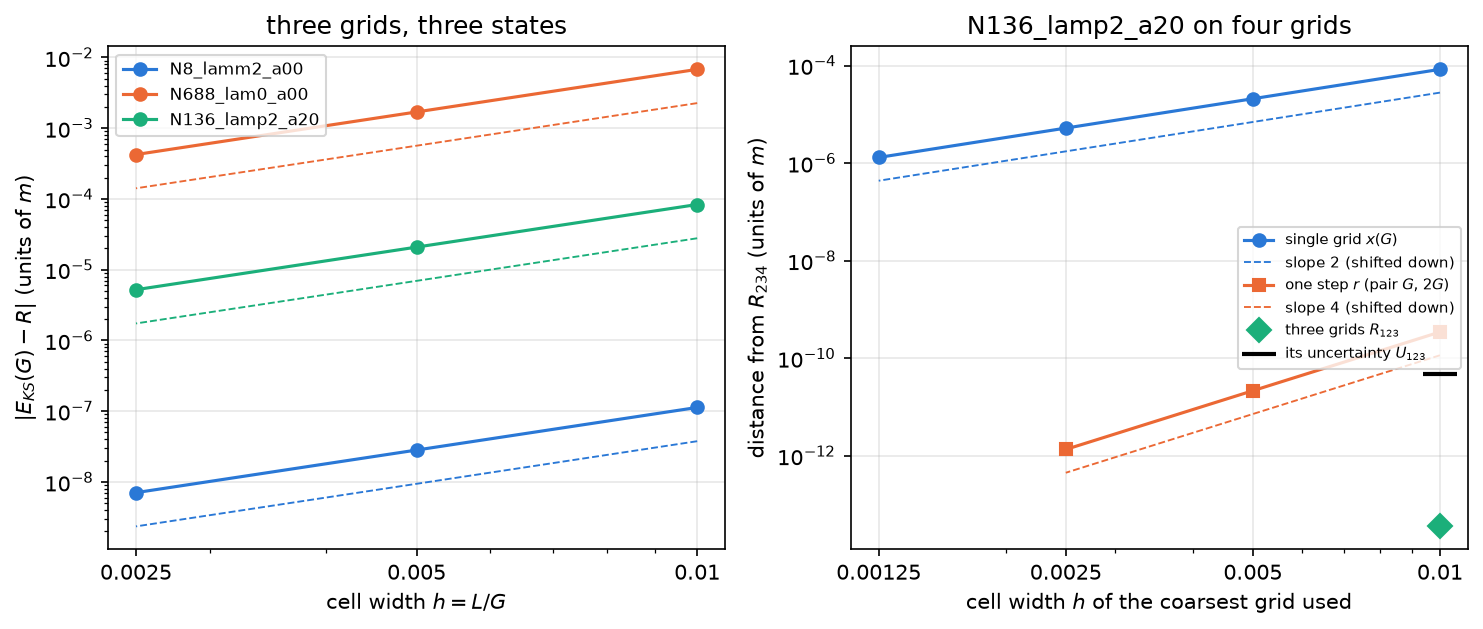

Figure 16a.1 saved as Revision/textbook/figures/16a_1_grid_convergence.png
PASS the errors shrink grid by grid and R123 lies within U123 of R234


In [8]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.3))
h = np.array([3.0 / 300, 3.0 / 600, 3.0 / 1200])  # the cell widths
for colour, sid in zip(PALETTE, GROUND_IDS):
    xs, R = CONVERGENCE[sid]
    left.loglog(h, [abs(x - R) for x in xs], "o-", color=colour, lw=1.5, ms=6,
                label=sid)
    first = abs(xs[0] - R)  # a guide of slope 2, a factor 3 below the first point
    left.loglog(h, first / 3.0 * (h / h[0]) ** 2, "--", color=colour, lw=0.9)
left.set_xlabel("cell width $h = L/G$")
left.set_ylabel("$|E_{KS}(G) - R|$ (units of $m$)")
left.set_title("three grids, three states")
left.legend(fontsize=8)

grids = [300, 600, 1200, 2400]
e4 = [FOUR_GRIDS[G][0] for G in grids]  # E_KS of N136_lamp2_a20 on the four grids
h4 = np.array([3.0 / G for G in grids])
R123, U123, _, _ = richardson(*e4[:3])
R234, _, _, _ = richardson(*e4[1:])
single = [abs(x - R234) for x in e4]
one_step = [abs((4.0 * e4[i + 1] - e4[i]) / 3.0 - R234) for i in range(3)]
right.loglog(h4, single, "o-", color=PALETTE[0], lw=1.5, ms=6,
             label="single grid $x(G)$")
right.loglog(h4, single[0] / 3.0 * (h4 / h4[0]) ** 2, "--", color=PALETTE[0],
             lw=0.9, label="slope 2 (shifted down)")
right.loglog(h4[:3], one_step, "s-", color=PALETTE[1], lw=1.5, ms=6,
             label="one step $r$ (pair $G$, $2G$)")
right.loglog(h4[:3], one_step[0] / 3.0 * (h4[:3] / h4[0]) ** 4, "--",
             color=PALETTE[1], lw=0.9, label="slope 4 (shifted down)")
right.loglog([h4[0]], [max(abs(R123 - R234), 1e-16)], "D", color=PALETTE[2], ms=8,
             label="three grids $R_{123}$")
right.loglog([h4[0]], [U123], "_", color="k", ms=16, mew=2,
             label="its uncertainty $U_{123}$")
right.set_xlabel("cell width $h$ of the coarsest grid used")
right.set_ylabel("distance from $R_{234}$ (units of $m$)")
right.set_title("N136_lamp2_a20 on four grids")
right.legend(fontsize=7, loc="center right")
for ax, ticks in ((left, h), (right, h4)):  # tick labels at the grids' h only
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t:g}" for t in ticks])
fig.tight_layout()
save_figure(fig, "grid_convergence",
            "Convergence of the reference solver for the Kohn-Sham energy $E_{KS}$, "
            "logarithmic axes, energies in units of the mass $m$. Left: distance of "
            "the single-grid value from the Richardson value $R$ against the cell "
            "width $h = 3/G$ for $G = 300, 600, 1200$ for the three ground states; "
            "the points run parallel to the dashed lines of slope 2 (drawn a factor 3 "
            "lower), an error proportional to $h^2$. Right: the state N136_lamp2_a20 "
            "also on $G = 2400$, every "
            "distance measured from the four-grid best value $R_{234}$: single grids "
            "fall with slope 2, one Richardson step with slope 4, and the three-grid "
            "value $R_{123}$ (diamond) lies far below its stated uncertainty "
            "$U_{123}$ (bar), so $U$ is a safe over-estimate.")
check(all(abs(CONVERGENCE[s][0][0] - CONVERGENCE[s][1])
          > abs(CONVERGENCE[s][0][2] - CONVERGENCE[s][1]) for s in GROUND_IDS)
      and single[0] > single[1] > single[2] > single[3]
      and one_step[0] > one_step[1] > one_step[2] and abs(R123 - R234) <= U123,
      "the errors shrink grid by grid and R123 lies within U123 of R234")

The next figure draws the result of the validation for all 19 classes: for each
class the largest value of $|R_{123} - R_{234}|/U_{123}$ over its elements. A bar
that stays left of the line 1 means that the stated uncertainty covers the change.
A class whose largest value is exactly zero (the two three-grid values agree in every
digit) is drawn at $10^{-8}$.

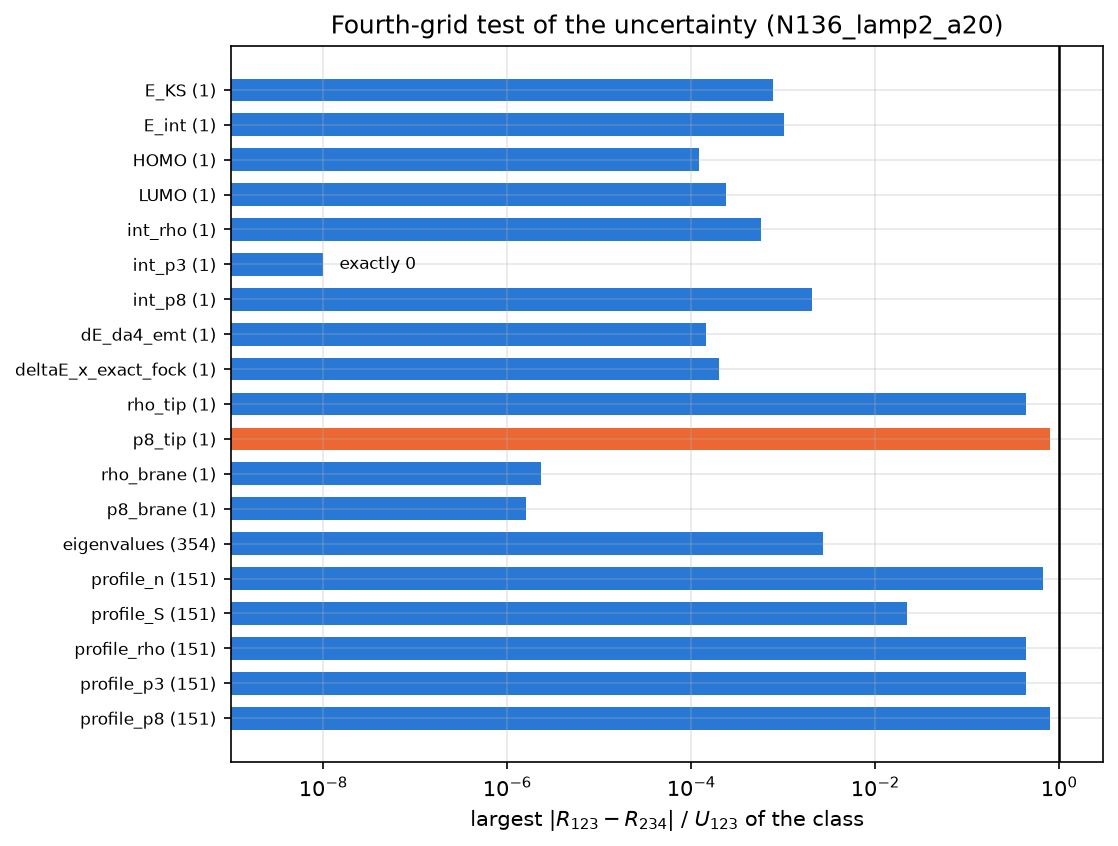

Figure 16a.2 saved as Revision/textbook/figures/16a_2_uncertainty_validated.png


In [9]:
names = list(classes)  # the 19 classes in the order of the record
values = [max(classes[n]["max_ratio_to_U123"], 1e-8) for n in names]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
colours = [PALETTE[1] if n == worst else PALETTE[0] for n in names]
ax.barh(range(len(names)), values, color=colours, height=0.65)
ax.set_xscale("log")
ax.axvline(1.0, color="k", lw=1.2)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([f"{n} ({classes[n]['elements']})" for n in names], fontsize=8)
ax.invert_yaxis()  # the first class at the top
ax.set_xlim(1e-9, 3.0)
for i, n in enumerate(names):
    if classes[n]["max_ratio_to_U123"] == 0.0:  # mark a class that agrees exactly
        ax.text(1.5e-8, i, "exactly 0", va="center", fontsize=8)
ax.set_xlabel("largest $|R_{123} - R_{234}|$ / $U_{123}$ of the class")
ax.set_title("Fourth-grid test of the uncertainty (N136_lamp2_a20)")
save_figure(fig, "uncertainty_validated",
            "Validation of the reference uncertainty on a fourth grid for the state "
            "N136_lamp2_a20: for each of the 19 classes of quantities (the number of "
            "elements in brackets) the largest change of the three-grid value between "
            "the grids $(300, 600, 1200)$ and $(600, 1200, 2400)$, divided by the "
            "stated uncertainty $U_{123}$, on a logarithmic axis; a class that agrees "
            f"exactly is drawn at $10^{{-8}}$ and marked. All bars end left of the "
            "line 1; the largest, "
            f"{classes[worst]['max_ratio_to_U123']:.3f}, is the value of $p_8$ at the "
            "tip, where the densities are largest.")

## 10. Every level converges like $h^2$

The ratio test can be made for every level, not only for $E_{KS}$. The next cell
computes, for every level of the three ground states, the ratio
$(x(300) - x(600))/(x(600) - x(1200))$ with the reference program's own function
`RR.asym_ratio` (it leaves out levels whose differences are below $10^{-10}$, where
rounding would dominate), and compares the median, smallest and largest ratio with
the values stored in the record (entry `consistency`). Then it draws, for every
level, the distance of its ratio from 4 against the level's energy. The reference's
check `richardson_asymptotic_ratio` requires the median to lie within 0.05 of 4.

N8_lamm2_a00: 22 levels, median ratio 4.000053, smallest 3.999954, largest 4.000506
PASS the levels of N8_lamm2_a00 converge like h^2 (median ratio within 0.05 of 4)
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    richardson_asymptotic_ratio
N688_lam0_a00: 135 levels, median ratio 4.000064, smallest 3.999959, largest 4.000220
PASS the levels of N688_lam0_a00 converge like h^2 (median ratio within 0.05 of 4)
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    richardson_asymptotic_ratio
N136_lamp2_a20: 354 levels, median ratio 4.000055, smallest 3.999269, largest 4.033570
PASS the levels of N136_lamp2_a20 converge like h^2 (median ratio within 0.05 of 4)
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    richardson_asymptotic_ratio


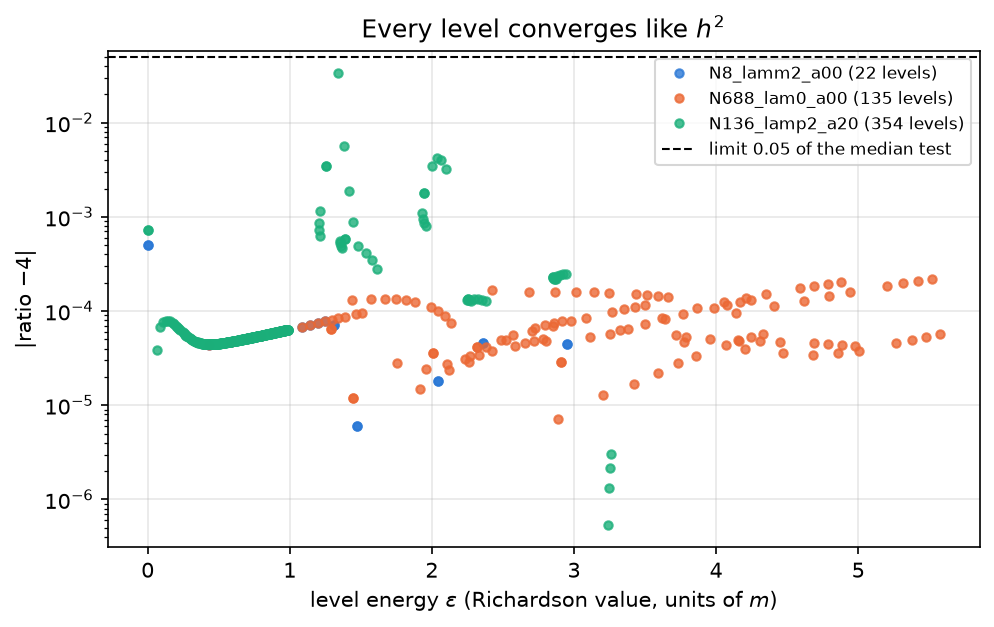

Figure 16a.3 saved as Revision/textbook/figures/16a_3_eigenvalue_ratios.png
PASS every single level has a ratio within 0.05 of 4


In [10]:
level_points = []  # (state, level energy, ratio) of every level with a ratio
for sid in GROUND_IDS:
    eps = [PER_GRID[(sid, G)] for G in (300, 600, 1200)]
    ratios = RR.asym_ratio(*eps)  # the reference's own function
    stored = NEW[sid]["consistency"]["ratio_eps"]
    mine = (len(ratios), float(np.median(ratios)), min(ratios), max(ratios))
    say(f"{sid}: {mine[0]} levels, median ratio {mine[1]:.6f}, smallest "
        f"{mine[2]:.6f}, largest {mine[3]:.6f}")
    check(mine == (stored["count"], stored["median"], stored["min"], stored["max"])
          and abs(mine[1] - 4.0) <= 0.05,
          f"the levels of {sid} converge like h^2 (median ratio within 0.05 of 4)",
          record=f"{KS}/reports/ks-reference.json, check richardson_asymptotic_ratio")
    floor = 1e-10  # the same selection as asym_ratio: both differences above 1e-10
    d1, d2 = eps[0] - eps[1], eps[1] - eps[2]
    keep = (np.abs(d1) > floor) & (np.abs(d2) > floor)
    energies = np.asarray(NEW[sid]["levels"]["eps"])[keep]
    level_points += [(sid, e, r) for e, r in zip(energies, d1[keep] / d2[keep])]

fig, ax = plt.subplots(figsize=(7.5, 4.3))
for colour, sid in zip(PALETTE, GROUND_IDS):
    pts = [(e, abs(r - 4.0)) for s, e, r in level_points if s == sid]
    ax.semilogy([p[0] for p in pts], [p[1] for p in pts], "o", color=colour, ms=4,
                alpha=0.8, label=f"{sid} ({len(pts)} levels)")
ax.axhline(0.05, color="k", lw=1.0, ls="--", label="limit 0.05 of the median test")
ax.set_xlabel("level energy $\\varepsilon$ (Richardson value, units of $m$)")
ax.set_ylabel("$|$ratio $- 4|$")
ax.set_title("Every level converges like $h^2$")
ax.legend(fontsize=8)
worst_level = max(abs(r - 4.0) for _, _, r in level_points)
save_figure(fig, "eigenvalue_ratios",
            "Distance from 4 of the convergence ratio $(x(300) - x(600))/(x(600) - "
            "x(1200))$ of every level of the three ground states, against the "
            "level energy in units of $m$ (vertical axis logarithmic). A ratio of 4 "
            "means an error proportional to $h^2$. Most levels lie between "
            "$10^{-5}$ and $3\\times10^{-4}$ from 4, with no trend in the energy; "
            "the levels nearest $\\varepsilon = 0$ deviate by $5\\times10^{-4}$ to "
            "$7\\times10^{-4}$. The largest deviations belong to a group of levels "
            "of N136_lamp2_a20 between $\\varepsilon = 1.2$ and $2.1$; even the worst "
            f"level, at {worst_level:.4f}, stays below the limit 0.05 that the "
            "reference applies to the median.")
check(worst_level < 0.05, "every single level has a ratio within 0.05 of 4")

## 11. The two thermal states on the reference

The next cell runs the reference program's thermal job for the two thermal states,
compares the results with the committed files
`Revision/kohn_sham/reference/results/thermo/<id>.json` in the same way, and prints
the chemical potential $\mu$, the energy $E$ and the heat capacity $C_V$ with their
uncertainties. The state N8_lamm1_a00_T10 is the one in which the first cross-check
failed (the Rust value of $\mu$ was $8.3\times10^{-10}$ too small, about 100 times
the tolerance); Notebook 16c of this chapter tells that story and reproduces the
faulty value digit for digit.

In [11]:
for sid in THERMAL_IDS:
    NEW[sid] = RR.jsonable(RR.thermo_job(CO, SPECS[sid])["data"])
    th = NEW[sid]["thermo"]
    say(f"{sid}: {NEW[sid]['levels_in_set']} levels; mu = {th['mu']['value']:.13f} "
        f"(U {th['mu']['U']:.1e}), E = {th['E']['value']:.12f} (U {th['E']['U']:.1e}),"
        f" C_V = {th['C_V']['value']:.9f} (U {th['C_V']['U']:.1e})")
    check_reproduction(sid, NEW[sid], f"{KS}/reference/results/thermo/{sid}.json")

N8_lamm1_a00_T10: 8 levels; mu = 0.2100104497343 (U 2.3e-12), E = 0.000986845293 (U
    2.0e-12), C_V = 0.000005755 (U 2.0e-12)
N8_lamm1_a00_T10: 259 numbers compared; identical byte for byte: True
PASS the re-run of N8_lamm1_a00_T10 reproduces thermo/N8_lamm1_a00_T10.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_byte_identical
N8_lam0_a15_T50: 474 levels; mu = -0.0304029805513 (U 2.1e-12), E = 0.950242831973 (U
    2.6e-12), C_V = 32.379779710 (U 8.0e-11)
N8_lam0_a15_T50: 6537 numbers compared; identical byte for byte: True
PASS the re-run of N8_lam0_a15_T50 reproduces thermo/N8_lam0_a15_T50.json
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    reference_repeat_byte_identical


## 12. The Rust solver: canonical and refined runs

The next cell builds the Rust solver with cargo (a second when it is already built)
and runs its command `single` for each state twice: with the canonical numerics and
with `--refined`. The arguments are exactly those of the cross-check's measurement
program `measure_rust_refinement.py`: the mass $m = 1$, the coupling, the slice, $N$,
the temperature for thermal states, and the **margin**, which decides how many levels
above the Fermi level are kept ($0.25 + 2\sigma$ at $T = 0$, $0.2 + 2\sigma$ at
$T > 0$). Each run writes a JSON file (energies, levels, integrals) and a CSV file
(the profiles) into a new **temporary folder** of the operating system, outside the
repository; the cell reads them back and then deletes the folder, so the runs leave
no file behind. It prints each command without the two output-file options (their
folder differs from run to run).

In [12]:
SOLVER = rust_program(f"{KS}/solver/Cargo.toml", "revision_ks_solver")
RUN_FOLDER = Path(tempfile.mkdtemp(prefix="textbook_16a_"))  # a new, empty folder


def run_single(sid, refined):
    """Run `revision_ks_solver single` for state sid; return (results, profiles,
    the arguments without the output files)."""
    spec = SPECS[sid]
    margin = (0.2 if "T" in spec else 0.25) + 2.0 * spec["sigma"]
    stem = f"{sid}_{'refined' if refined else 'canonical'}"
    arguments = ["single", "--m", "1", "--lambda", repr(spec["lam"]),
                 "--a4", repr(spec["a4"]), "--N", repr(spec["N"]),
                 "--margin", repr(margin)]
    if "T" in spec:
        arguments += ["--T", repr(spec["T"])]
    if refined:
        arguments.append("--refined")
    files = ["--out", f"{RUN_FOLDER / stem}.json",
             "--profiles", f"{RUN_FOLDER / stem}.csv"]
    done = subprocess.run([str(SOLVER)] + arguments + files, cwd=str(REPO),
                          capture_output=True, text=True)
    if done.returncode != 0 or not done.stdout.strip().endswith("SUCCESS"):
        print(done.stderr[-2000:])
        raise RuntimeError(f"the Rust run {stem} failed")
    results = json.loads((RUN_FOLDER / f"{stem}.json").read_text(encoding="utf-8"))
    with open(RUN_FOLDER / f"{stem}.csv", newline="", encoding="utf-8") as handle:
        profiles = [{k: float(v) for k, v in row.items()}
                    for row in csv.DictReader(handle)]
    return results, profiles, arguments


RUST = {}  # (state id, "canonical" or "refined") -> (results, profiles)
for sid in SPECS:
    for refined in (False, True):
        results, profiles, arguments = run_single(sid, refined)
        RUST[(sid, "refined" if refined else "canonical")] = (results, profiles)
    say("revision_ks_solver " + " ".join(arguments))  # the refined command
shutil.rmtree(RUN_FOLDER)  # delete the temporary folder and the raw outputs in it
check(len(RUST) == 10, "ten Rust runs (five states, two numerics) completed")

Rust program revision_ks_solver is built and ready.
revision_ks_solver single --m 1 --lambda -0.05838 --a4 0.0 --N 8.0 --margin 0.85
    --refined
revision_ks_solver single --m 1 --lambda 0.0 --a4 0.0 --N 688.0 --margin 0.25 --refined
revision_ks_solver single --m 1 --lambda 0.002789 --a4 2.0 --N 136.0 --margin 0.85
    --refined
revision_ks_solver single --m 1 --lambda -0.01946 --a4 0.0 --N 8.0 --margin 0.4 --T 0.01
    --refined
revision_ks_solver single --m 1 --lambda 0.0 --a4 1.5 --N 8.0 --margin 0.2 --T 0.05
    --refined
PASS ten Rust runs (five states, two numerics) completed


The measured differences are only meaningful if the canonical `single` run gives
exactly the committed canonical results. The next cell checks this, as the
cross-check's check `rust_refinement_applies_to_matrix` does: for the ground states
$E_{KS}$, the five energy-momentum integrals, every level and every profile point;
for the thermal states $E$, $\mu$ and the entropy; each must agree with the committed
files within $10^{-12}$ (relative to $\max(1,|x|)$ or to the profile's largest value).
Then it computes the canonical-minus-refined differences of $E_{KS}$, of the levels and
(for thermal states) of $\mu$ and checks that they equal the values recorded in
`Revision/kohn_sham/checker/rust-refinement.json`.

In [13]:
SUMMARY = {r["id"]: r for r in read_csv(f"{KS}/results/ground/summary.csv")}
EMT = {r["id"]: r for r in read_csv(f"{KS}/results/ground/emt-integrals.csv")}
EXCITED = {r["id"]: r for r in read_csv(f"{KS}/results/excited/summary.csv")}
ADIABATIC = {r["id"]: r for r in read_csv(f"{KS}/results/adiabatic/adiabaticity.csv")}
THERMO = {r["id"]: r for r in read_csv(f"{KS}/results/thermo/thermodynamics.csv")}
REFINEMENT = {(s["kind"], s["id"]): s
              for s in read_json(f"{KS}/checker/rust-refinement.json")["states"]}


def rel(a, b):
    """|a - b| relative to max(1, |b|)."""
    return abs(a - b) / max(1.0, abs(b))


def level_map(results):
    """{(n2, j, parity, label): eps} of the levels of a `single` run."""
    return {tuple(l[:4]): l[4] for l in results["levels_n2_j_parity_label_eps_deg_f"]}


for sid in SPECS:
    canon, canon_prof = RUST[(sid, "canonical")]
    refined, _ = RUST[(sid, "refined")]
    if sid in GROUND_IDS:
        worst = rel(canon["E_KS"], float(SUMMARY[sid]["E_KS"]))
        integrals = canon["emtIntegrals_2Vol7_int_e6Hy"]
        for k in ("rho", "p3", "p_t", "p8", "n"):
            worst = max(worst, rel(integrals[k], float(EMT[sid]["int_" + k])))
        committed = {(int(x["n2"]), int(x["j"]), x["parity"], int(x["label"])):
                     float(x["eps"])
                     for x in read_csv(f"{KS}/results/ground/levels/{sid}.csv")}
        mine = level_map(canon)
        worst = max([worst] + [abs(mine[k] - committed[k]) for k in mine
                               if k in committed])
        stored_prof = read_csv(f"{KS}/results/ground/profiles/{sid}.csv")
        for name in ("n", "S", "rho", "p3", "p_t", "p8"):
            top = max(abs(float(row[name])) for row in stored_prof)
            worst = max([worst] + [abs(a[name] - float(b[name])) / max(top, 1e-300)
                                   for a, b in zip(canon_prof, stored_prof)])
        kind = "ground"
    else:
        row = THERMO[sid]
        worst = max(rel(canon["E_KS"], float(row["E"])),
                    abs(canon["mu_or_fermi_level"] - float(row["mu"])),
                    abs(canon["entropy"] - float(row["entropy"]))
                    / max(1e-6, abs(float(row["entropy"]))))
        kind = "thermo"
    rec = REFINEMENT[(kind, sid)]
    lc, lr = level_map(canon), level_map(refined)
    level_diff = max(abs(lc[k] - lr[k]) for k in lc if k in lr)
    e_diff = abs(canon["E_KS"] - refined["E_KS"])
    say(f"{sid}: largest difference from the committed results {worst:.1e}; "
        f"|canonical - refined|: E_KS {e_diff:.3e}, levels {level_diff:.3e}")
    same = (abs(e_diff - rec["scalars"]["E_KS"]["abs_diff"])
            <= 1e-12 * max(1.0, abs(canon["E_KS"]))
            and abs(level_diff - rec["levels"]["max_abs_diff"]) <= 1e-12)
    if kind == "thermo":
        mu_diff = abs(canon["mu_or_fermi_level"] - refined["mu_or_fermi_level"])
        same = same and abs(mu_diff - rec["scalars"]["mu"]["abs_diff"]) <= 1e-12
    check(worst <= 1e-12, f"the canonical run of {sid} reproduces the committed "
                          "Rust results",
          record=f"{KS}/reports/ks-crosscheck.json, check "
                 "rust_refinement_applies_to_matrix")
    check(same, f"canonical minus refined of {sid} reproduces the measured values",
          record=f"{KS}/checker/rust-refinement.json, state {kind} {sid}")

N8_lamm2_a00: largest difference from the committed results 0.0e+00; |canonical -
    refined|: E_KS 1.139e-13, levels 3.738e-10
PASS the canonical run of N8_lamm2_a00 reproduces the committed Rust results
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    rust_refinement_applies_to_matrix
PASS canonical minus refined of N8_lamm2_a00 reproduces the measured values
     reproduces Revision/kohn_sham/checker/rust-refinement.json, state ground
    N8_lamm2_a00
N688_lam0_a00: largest difference from the committed results 0.0e+00; |canonical -
    refined|: E_KS 7.529e-10, levels 2.135e-09
PASS the canonical run of N688_lam0_a00 reproduces the committed Rust results
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    rust_refinement_applies_to_matrix
PASS canonical minus refined of N688_lam0_a00 reproduces the measured values
     reproduces Revision/kohn_sham/checker/rust-refinement.json, state ground
    N688_lam0_a00
N136_lamp2_a20: largest diff

## 13. The tolerance rule in a few lines of Python

The next cell writes the rule as a function. `compare` receives the class, the case
name, the Rust value, the reference value, the two uncertainties and (for profile
points) the scale; it computes the tolerance and the ratio exactly as the cross-check
program does and stores a row in the list `ROWS`. The cell also computes, for every
state, the Rust uncertainties $U_{Rust} = \tfrac{16}{15}|canonical - refined|$ of
every quantity the `single` command reports, and reads the **matrix-wide** Rust
uncertainties that the cross-check uses for quantities that `single` does not report
(Delta-SCF, $Q_{max}$, $dE/da_4$ by differences, $C_V$); they are the largest
canonical-minus-refined differences of the whole Rust matrix, recorded in the
cross-check report. Finally it shows every piece of one comparison, $E_{KS}$ of
N8_lamm2_a00.

In [14]:
RK4_FACTOR = 16.0 / 15.0  # canonical error = (16/15) |canonical - refined|
ROWS = []  # (class, case, x_Rust, x_ref, U_ref, U_Rust, tolerance, |diff|, ratio)


def compare(cls, case, x_rust, x_ref, u_ref, u_rust, scale=None):
    """The tolerance rule of the cross-check; returns the ratio."""
    scale = max(1.0, abs(x_ref)) if scale is None else scale
    tolerance = 3.0 * (u_ref + u_rust) + 1e-12 * scale
    diff = abs(x_rust - x_ref)
    ratio = diff / tolerance
    ROWS.append((cls, case, x_rust, x_ref, u_ref, u_rust, tolerance, diff, ratio))
    return ratio


PROFILE_NAMES = ("n", "S", "Q", "M_eff", "v_v", "e_int", "rho", "p3", "p_t", "p8")


def rust_uncertainties(sid):
    """U_Rust of every quantity reported by `single`, for state sid."""
    (canon, cp), (refined, rp) = RUST[(sid, "canonical")], RUST[(sid, "refined")]
    U = {k: RK4_FACTOR * abs(canon[k] - refined[k])
         for k in ("E_KS", "E_band", "E_int", "entropy")}
    U["mu"] = RK4_FACTOR * abs(canon["mu_or_fermi_level"]
                               - refined["mu_or_fermi_level"])
    ci, ri = canon["emtIntegrals_2Vol7_int_e6Hy"], refined["emtIntegrals_2Vol7_int_e6Hy"]
    for k in ("rho", "p3", "p_t", "p8", "n"):
        U["int_" + k] = RK4_FACTOR * abs(ci[k] - ri[k])
    for k in ("rho", "p3", "p_t", "p8"):  # profile end points: brane and tip
        U[k + "_brane"] = RK4_FACTOR * abs(cp[-1][k] - rp[-1][k])
        U[k + "_tip"] = RK4_FACTOR * abs(cp[0][k] - rp[0][k])
    lc, lr = level_map(canon), level_map(refined)
    U["levels"] = RK4_FACTOR * max(abs(lc[k] - lr[k]) for k in lc if k in lr)
    for name in PROFILE_NAMES:  # (U of the profile, largest |value|)
        U["profile_" + name] = (
            RK4_FACTOR * max(abs(a[name] - b[name]) for a, b in zip(cp, rp)),
            max(abs(a[name]) for a in cp))
    return U


U_RUST = {sid: rust_uncertainties(sid) for sid in SPECS}
WIDE = REPORTS["cross-check"]["rust_matrix_wide_uncertainties"]
say("matrix-wide Rust differences: " + ", ".join(
    f"{k.replace('refined_', '')} {v:.2e}" for k, v in sorted(WIDE.items())))

sid = "N8_lamm2_a00"  # one comparison, piece by piece
x_rust = float(SUMMARY[sid]["E_KS"])
x_ref = NEW[sid]["scalars"]["E_KS"]["value"]
u_ref = NEW[sid]["scalars"]["E_KS"]["U"]
u_rust = U_RUST[sid]["E_KS"]
ratio = compare("ground_energies", f"{sid} E_KS", x_rust, x_ref, u_ref, u_rust)
say(f"E_KS of {sid}: Rust {x_rust!r}, reference {x_ref!r}")
say(f"    |diff| = {abs(x_rust - x_ref):.3e}, U_ref = {u_ref:.3e}, "
    f"U_Rust = {u_rust:.3e}")
say(f"    tolerance = 3 (U_ref + U_Rust) + 1e-12 max(1, |x|) = {ROWS[-1][6]:.3e}, "
    f"ratio = {ratio:.4f}")
check(ratio <= 1.0, f"E_KS of {sid} agrees within the tolerance")

matrix-wide Rust differences: adiabatic_derivatives 9.02e-10, delta_scf 5.82e-11,
    eigenvalues 2.14e-09, ground_energies 1.90e-12, ground_homo_lumo_gap 1.30e-12,
    heat_capacity 5.69e-09, profiles 2.80e-09, thermodynamics 2.49e-10
E_KS of N8_lamm2_a00: Rust 0.002862652173608389, reference 0.002862652173734779
    |diff| = 1.264e-13, U_ref = 2.096e-12, U_Rust = 1.214e-13
    tolerance = 3 (U_ref + U_Rust) + 1e-12 max(1, |x|) = 7.651e-12, ratio = 0.0165
PASS E_KS of N8_lamm2_a00 agrees within the tolerance


## 14. The ground-state comparisons

The next cell makes, for the three ground states, the comparisons of the cross-check
program's ground-state classes (the class names are the names of its checks):

- `ground_energies`: $E_{KS}$, $E_{band}$, $E_{int}$ with $U_{Rust}$ measured;
- `ground_homo_lumo_gap`: HOMO and LUMO with $U_{Rust}$ = the largest level
  uncertainty of the state, the gap with twice that;
- `ground_eigenvalues`: every level present in both label sets, key by key (a Rust
  label is turned into a rank by subtracting `label_min`);
- `excited_delta_scf`: Delta-SCF and $E_{excited}$, with the matrix-wide Delta-SCF
  uncertainty;
- `ground_occupations_and_groups` (not a ratio): the same occupied levels.

The uncertainties were measured in the cells above. The comparisons of the
energy-momentum tensor follow in the cell after this one.

In [15]:
def rank_key(n2, j, parity, rank):
    """The level key n2:j:parity:rank as a text, for example 1:-1:even:2."""
    return f"{int(n2)}:{'+1' if int(j) > 0 else '-1'}:{parity}:{int(rank)}"


U_DSCF = RK4_FACTOR * WIDE["refined_delta_scf"]  # matrix-wide Delta-SCF uncertainty
for sid in GROUND_IDS:
    sc, U = NEW[sid]["scalars"], U_RUST[sid]
    for k in ("E_KS", "E_band", "E_int"):
        if not (sid == "N8_lamm2_a00" and k == "E_KS"):  # made in section 13
            compare("ground_energies", f"{sid} {k}", float(SUMMARY[sid][k]),
                    sc[k]["value"], sc[k]["U"], U[k])
    for k, u in (("HOMO", U["levels"]), ("LUMO", U["levels"]),
                 ("KS_gap", 2.0 * U["levels"])):
        compare("ground_homo_lumo_gap", f"{sid} {k}", float(SUMMARY[sid][k]),
                sc[k]["value"], sc[k]["U"], u)
    rust_levels = {}  # key -> (eps, occupation) of the committed Rust levels
    for x in read_csv(f"{KS}/results/ground/levels/{sid}.csv"):
        rank = int(x["label"]) - int(x["label_min"])
        rust_levels[rank_key(x["n2"], x["j"], x["parity"], rank)] = (
            float(x["eps"]), float(x["f"]))
    lev = NEW[sid]["levels"]
    ref_levels = {rank_key(*k): (e, u, f)
                  for k, e, u, f in zip(lev["keys"], lev["eps"], lev["U"], lev["f"])}
    common = sorted(set(rust_levels) & set(ref_levels))
    for k in common:
        compare("ground_eigenvalues", f"{sid} level {k}", rust_levels[k][0],
                ref_levels[k][0], ref_levels[k][1], U["levels"])
    occupied_rust = sorted(k for k, v in rust_levels.items() if v[1] > 0)
    occupied_ref = sorted(k for k, v in ref_levels.items() if v[2] > 0)
    compare("excited_delta_scf", f"{sid} delta_SCF", float(EXCITED[sid]["delta_SCF"]),
            sc["delta_SCF"]["value"], sc["delta_SCF"]["U"], U_DSCF)
    compare("excited_delta_scf", f"{sid} E_excited", float(EXCITED[sid]["E_excited"]),
            sc["E_excited"]["value"], sc["E_excited"]["U"], U["E_KS"] + U_DSCF)
    say(f"{sid}: {len(rust_levels)} Rust levels, {len(ref_levels)} reference levels, "
        f"{len(common)} compared; {len(occupied_rust)} occupied in both")
    check(occupied_rust == occupied_ref, f"the same occupied levels in {sid}",
          record=f"{KS}/reports/ks-crosscheck.json, check "
                 "ground_occupations_and_groups")

N8_lamm2_a00: 64 Rust levels, 22 reference levels, 22 compared; 2 occupied in both
PASS the same occupied levels in N8_lamm2_a00
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    ground_occupations_and_groups
N688_lam0_a00: 164 Rust levels, 137 reference levels, 137 compared; 12 occupied in both
PASS the same occupied levels in N688_lam0_a00
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    ground_occupations_and_groups
N136_lamp2_a20: 1248 Rust levels, 354 reference levels, 354 compared; 6 occupied in both
PASS the same occupied levels in N136_lamp2_a20
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    ground_occupations_and_groups


The next cell adds the comparisons of the energy-momentum tensor and of the
adiabaticity, again in the classes of the cross-check program:

- `emt_integrals`: the five integrals $\int\rho$, $\int p_3$, $\int p_t$, $\int p_8$,
  $\int n$;
- `emt_brane_tip_values`: $\rho$, $p_3$, $p_t$, $p_8$ at the brane and at the tip;
- `ground_profiles`: the ten profiles at all 151 points, with the scale = the
  largest value of the profile;
- `exchange_delta_E_x`: $\Delta E_x$, whose Rust uncertainty is derived from the
  measured uncertainty of the profile $Q$ (twice its relative size, because
  $\Delta E_x$ is quadratic in $Q$);
- `adiabatic_dE_da4`: $dE/da_4$ in its energy-momentum form (uncertainty from the
  integrals of $p_3$ and $p_t$) and as a difference quotient (matrix-wide);
- `adiabatic_Q_max`: $Q_{max}$, and when it is not zero also its matrix element and
  its level spacing; the maximising pair of levels must be the same.

The pair of levels of $Q_{max}$ is printed with the Rust labels and the reference
ranks; for the sector of that pair (even parity, $j = +1$) the lowest particle label
is 0, so labels and ranks coincide.

In [16]:
U_ADIABATIC = RK4_FACTOR * WIDE["refined_adiabatic_derivatives"]  # relative
for sid in GROUND_IDS:
    sc, U, e = NEW[sid]["scalars"], U_RUST[sid], EMT[sid]
    for k in ("rho", "p3", "p_t", "p8", "n"):
        compare("emt_integrals", f"{sid} int_{k}", float(e["int_" + k]),
                sc["int_" + k]["value"], sc["int_" + k]["U"], U["int_" + k])
    for k in ("rho", "p3", "p_t", "p8"):
        for end in ("brane", "tip"):
            name = f"{k}_{end}"
            compare("emt_brane_tip_values", f"{sid} {name}", float(e[name]),
                    sc[name]["value"], sc[name]["U"], U[name])
    stored = read_csv(f"{KS}/results/ground/profiles/{sid}.csv")
    for name in PROFILE_NAMES:
        values = [float(row[name]) for row in stored]
        top = max(max(abs(v) for v in values), 1e-300)  # the scale of the profile
        ref = NEW[sid]["profiles"][name]
        for i, row in enumerate(stored):
            compare("ground_profiles", f"{sid} {name}(y = {float(row['y']):.2f})",
                    values[i], ref["value"][i], ref["U"][i],
                    U["profile_" + name][0], scale=top)
    u_q, top_q = U["profile_Q"]
    dex = float(e["deltaE_x_exact_fock"])
    compare("exchange_delta_E_x", f"{sid} deltaE_x", dex,
            sc["deltaE_x_exact_fock"]["value"], sc["deltaE_x_exact_fock"]["U"],
            RK4_FACTOR * 2.0 * (u_q / RK4_FACTOR) / max(top_q, 1e-300) * abs(dex))
    a = ADIABATIC[sid]
    compare("adiabatic_dE_da4", f"{sid} dE_da4_emt", float(a["dE_da4_emt"]),
            sc["dE_da4_emt"]["value"], sc["dE_da4_emt"]["U"],
            3.0 * (U["int_p3"] + U["int_p_t"]))
    fd = float(a["dE_da4_finite_difference"])
    compare("adiabatic_dE_da4", f"{sid} dE_da4_finite_difference", fd,
            sc["dE_da4_fd"]["value"], sc["dE_da4_fd"]["U"], U_ADIABATIC * abs(fd))
    q_rust, ad = float(a["Q_max"]), NEW[sid]["adiabatic"]
    compare("adiabatic_Q_max", f"{sid} Q_max", q_rust, ad["Q_max"], ad["U_Q_max"],
            U_ADIABATIC * abs(q_rust))
    if q_rust > 0:
        top = ad["top"][0]  # the reference's maximising pair
        hole, particle = [s.strip() for s in a["Q_max_pair"].split("->")]
        say(f"{sid}: Q_max = {q_rust:.10f} for the pair {hole} -> {particle} (Rust), "
            f"{top['hole']} -> {top['particle']} (reference)")
        check((hole, particle) == (top["hole"], top["particle"]),
              f"both solvers find the same maximising pair in {sid}")
        me = float(a["Q_max_matrix_element"])
        compare("adiabatic_Q_max", f"{sid} Q_max matrix element", me,
                top["matrix_element"], top["U_matrix_element"], U_ADIABATIC * abs(me))
        compare("adiabatic_Q_max", f"{sid} Q_max delta eps", float(a["Q_max_delta_eps"]),
                top["delta_eps"], top["U_delta_eps"], 2.0 * U["levels"])
ground_rows = [r for r in ROWS if r[1].split()[0] in GROUND_IDS]
say(f"{len(ground_rows)} ground-state comparisons so far")
check(all(r[8] <= 1.0 for r in ground_rows),
      "every ground-state comparison of the subset passes the tolerance rule")

N688_lam0_a00: Q_max = 0.0934505917 for the pair 11:+1:even:0 -> 11:+1:even:1 (Rust),
    11:+1:even:0 -> 11:+1:even:1 (reference)
PASS both solvers find the same maximising pair in N688_lam0_a00
N136_lamp2_a20: Q_max = 0.0421562349 for the pair 4:+1:even:0 -> 4:+1:even:1 (Rust),
    4:+1:even:0 -> 4:+1:even:1 (reference)
PASS both solvers find the same maximising pair in N136_lamp2_a20
5122 ground-state comparisons so far
PASS every ground-state comparison of the subset passes the tolerance rule


## 15. The thermal comparisons

The next cell makes the thermal comparisons of the two thermal states, in the
cross-check classes `thermo_state_functions` ($\mu$, $E$, $S$, $F$, $\Omega$ in both
of its forms) and `thermo_derivatives` ($C_V = T\,dS/dT$, $dE/dT$, $-dF/dT$). The
Rust uncertainties of $F = E - TS$ and $\Omega = F - \mu N$ are added up from those
of $E$, $S$ and $\mu$ ($U_F = U_E + T U_S$, $U_\Omega = U_F + N U_\mu$). $dE/dT$ and
$-dF/dT$ are difference quotients of energies over $dT = 0.01\,T$, so each solver's
noise floor is added: $N \times$ (the Rust root tolerance $10^{-13}$) $/dT$ and
$N \times 10^{-12}/dT$ for the reference.

Three classes of the full cross-check are not repeated here: the particle-hole
lists, the exact-Fock variant and the rescaling partners (other solver runs that this
subset does not make), and for thermal states the sea-hole diagnostic and the
40-digit chemical potential (Notebook 16c computes the latter for all 45 thermal
states with $N = 8$, among them N8_lamm1_a00_T10).

In [17]:
ROOT_TOLERANCE = RUST_PARAMS["numerics"]["rootTolerance"]  # 1e-13
U_HEAT = RK4_FACTOR * WIDE["refined_heat_capacity"]  # relative, matrix-wide
for sid in THERMAL_IDS:
    th, U, row = NEW[sid]["thermo"], U_RUST[sid], THERMO[sid]
    T, N = NEW[sid]["T"], NEW[sid]["N"]
    u_f = U["E_KS"] + T * U["entropy"]
    for k, u in (("mu", U["mu"]), ("E", U["E_KS"]), ("entropy", U["entropy"]),
                 ("F", u_f), ("Omega_direct", u_f + N * U["mu"]),
                 ("Omega_F_minus_muN", u_f + N * U["mu"])):
        compare("thermo_state_functions", f"{sid} {k}", float(row[k]),
                th[k]["value"], th[k]["U"], u)
    dT = 0.01 * T
    for k in ("C_V", "C_V_from_dEdT", "minus_dFdT"):
        x = float(row[k])
        quotient = k != "C_V"  # a difference quotient of energies
        compare("thermo_derivatives", f"{sid} {k}", x, th[k]["value"],
                th[k]["U"] + (N * 1e-12 / dT if quotient else 0.0),
                U_HEAT * max(abs(x), 1e-6)
                + (N * ROOT_TOLERANCE / dT if quotient else 0.0))
    r = next(r for r in ROWS if r[1] == f"{sid} mu")
    say(f"{sid}: mu Rust {r[2]!r}, reference {r[3]!r}, ratio {r[8]:.4f}")
thermal_rows = [r for r in ROWS if r[1].split()[0] in THERMAL_IDS]
say(f"{len(thermal_rows)} thermal comparisons; {len(ROWS)} comparisons in all")
check(len(ROWS) == 5140 and all(r[8] <= 1.0 for r in ROWS),
      "all 5140 comparisons of the subset pass the tolerance rule")

N8_lamm1_a00_T10: mu Rust 0.2100104497339036, reference 0.21001044973430544, ratio 0.0438
N8_lam0_a15_T50: mu Rust -0.03040298055041425, reference -0.03040298055126662, ratio
    0.0825
18 thermal comparisons; 5140 comparisons in all
PASS all 5140 comparisons of the subset pass the tolerance rule


## 16. Reproducing the committed cross-check report

The cross-check program wrote every comparison of single numbers into the table
`Revision/kohn_sham/reports/ks-crosscheck-table.csv` (levels and profile points are
too many; the report keeps only their worst case). The next cell finds every one of
our comparisons in that table and checks that our tolerance and ratio agree with the
stored ones to the four significant digits the table keeps. Then it reads, from the
sentences of the cross-check report, the worst ratio of six classes and the case
where it occurred, and checks that our subset contains exactly that case with that
ratio: the hardest comparisons of the whole cross-check were made again here.

In [18]:
TABLE = {r["case"]: r for r in read_csv(f"{KS}/reports/ks-crosscheck-table.csv")}
matched, largest = 0, 0.0
for cls, case, *_, tolerance, diff, ratio in ROWS:
    if case in TABLE:
        matched += 1
        stored = TABLE[case]
        largest = max(largest, abs(ratio - float(stored["ratio"])))
        if abs(ratio - float(stored["ratio"])) > 6e-4 or \
                abs(tolerance - float(stored["tolerance"])) > 1e-3 * tolerance:
            say(f"differs: {case}: {ratio:.4f} vs {stored['ratio']}")
say(f"{matched} of our comparisons are rows of the committed table; the largest "
    f"difference of the ratio is {largest:.1e}")
check(matched == 97 and largest <= 6e-4,
      "our tolerances and ratios equal the 97 matching rows of the committed table",
      record=f"{KS}/reports/ks-crosscheck-table.csv")

WORST_CASES = {}  # class -> (worst ratio in the report, its case)
pattern = re.compile(r"worst \|diff\|/tolerance ([0-9.]+) \((.+?): Rust ")
for c in REPORTS["cross-check"]["checks"]:
    found = pattern.search(c["detail"])
    if found and c["name"] in ("ground_eigenvalues", "ground_profiles",
                               "emt_brane_tip_values", "adiabatic_Q_max",
                               "thermo_state_functions", "thermo_derivatives"):
        WORST_CASES[c["name"]] = (float(found.group(1)), found.group(2))
for cls, (ratio, case) in sorted(WORST_CASES.items()):
    mine = max((r for r in ROWS if r[0] == cls), key=lambda r: r[8])
    say(f"{cls}: report {ratio:.3f} ({case}); this notebook {mine[8]:.3f} "
        f"({mine[1]})")
    check(mine[1] == case and abs(mine[8] - ratio) <= 6e-4,
          f"the worst case of {cls} is reproduced",
          record=f"{KS}/reports/ks-crosscheck.json, check {cls}")

97 of our comparisons are rows of the committed table; the largest difference of the
    ratio is 5.0e-05
PASS our tolerances and ratios equal the 97 matching rows of the committed table
     reproduces Revision/kohn_sham/reports/ks-crosscheck-table.csv
adiabatic_Q_max: report 0.314 (N136_lamp2_a20 Q_max matrix element); this notebook 0.314
    (N136_lamp2_a20 Q_max matrix element)
PASS the worst case of adiabatic_Q_max is reproduced
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check adiabatic_Q_max
emt_brane_tip_values: report 0.495 (N8_lamm2_a00 rho_tip); this notebook 0.495
    (N8_lamm2_a00 rho_tip)
PASS the worst case of emt_brane_tip_values is reproduced
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check emt_brane_tip_values
ground_eigenvalues: report 0.324 (N136_lamp2_a20 level 1:-1:even:2); this notebook 0.324
    (N136_lamp2_a20 level 1:-1:even:2)
PASS the worst case of ground_eigenvalues is reproduced
     reproduces Revision/kohn_sham/repo

## 17. The agreement in pictures

The next cell draws the levels of N136_lamp2_a20, the state with the largest level
ratio: for each of its compared levels the ratio $|x_{Rust} - x_{ref}|/$tolerance
against its energy. Every point lies below the line ratio = 1.

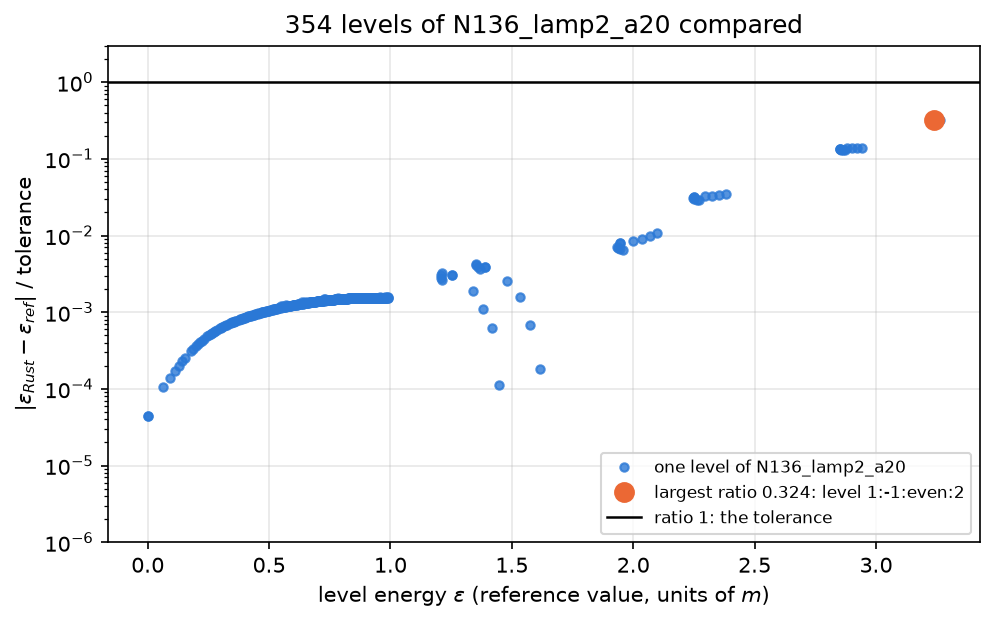

Figure 16a.4 saved as Revision/textbook/figures/16a_4_level_agreement.png
PASS all 354 levels of N136_lamp2_a20 agree within the tolerance


In [19]:
rows = [r for r in ROWS if r[0] == "ground_eigenvalues"
        and r[1].startswith("N136_lamp2_a20 ")]
worst = max(rows, key=lambda r: r[8])
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.semilogy([r[3] for r in rows], [max(r[8], 1e-6) for r in rows], "o",
            color=PALETTE[0], ms=4, alpha=0.8, label="one level of N136_lamp2_a20")
ax.semilogy([worst[3]], [worst[8]], "o", color=PALETTE[1], ms=9,
            label=f"largest ratio {worst[8]:.3f}: level "
                  f"{worst[1].split('level ')[1]}")
ax.axhline(1.0, color="k", lw=1.2, label="ratio 1: the tolerance")
ax.set_ylim(1e-6, 3.0)
ax.set_xlabel("level energy $\\varepsilon$ (reference value, units of $m$)")
ax.set_ylabel("$|\\varepsilon_{Rust} - \\varepsilon_{ref}|$ / tolerance")
ax.set_title(f"{len(rows)} levels of N136_lamp2_a20 compared")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "level_agreement",
            "Agreement of the two solvers for every level of the ground state "
            "N136_lamp2_a20 ($N = 136$, $\\lambda = +\\lambda_2$, $a_{4,0} = 2$): the "
            "difference of the two level energies divided by the tolerance $3(U_{ref} "
            "+ U_{Rust}) + 10^{-12}\\max(1, |\\varepsilon|)$, against the level energy "
            "in units of $m$ (vertical axis logarithmic; ratios below one millionth "
            "are drawn at $10^{-6}$). Every point lies below the line 1, so every "
            f"level passes; the largest ratio, {worst[8]:.3f}, is the largest of all "
            "9616 level comparisons of the full cross-check.")
check(len(rows) == 354 and worst[8] < 1.0,
      "all 354 levels of N136_lamp2_a20 agree within the tolerance")

The next cell draws the profile in which the largest ratio of the whole cross-check
occurred: the energy density $\rho(y)$ of N8_lamm2_a00. Top: $\rho$ from both
solvers (the reference at every fifth point). Bottom: the ratio at each of the 151
points for $\rho$ and for $p_8$.

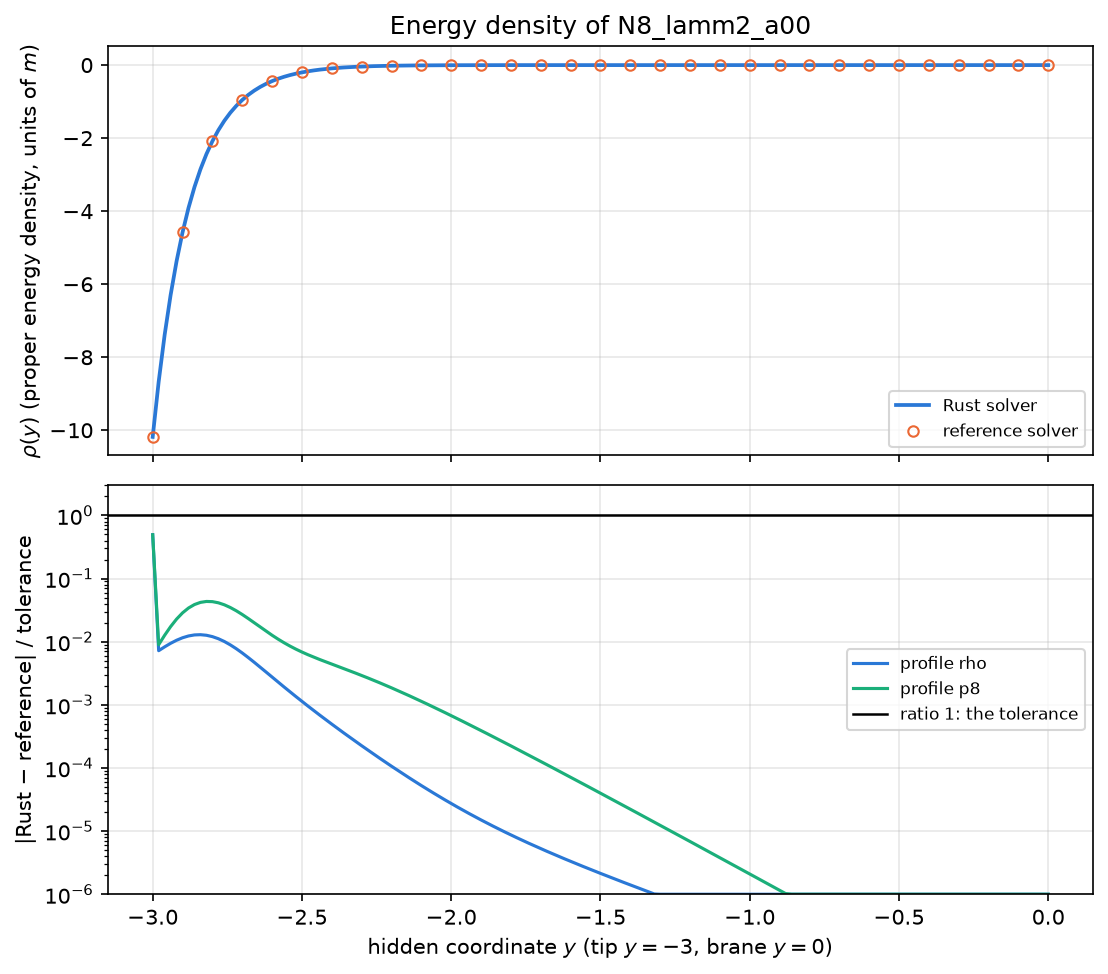

Figure 16a.5 saved as Revision/textbook/figures/16a_5_profile_agreement.png


In [20]:
sid = "N8_lamm2_a00"
stored = read_csv(f"{KS}/results/ground/profiles/{sid}.csv")
y = np.array([float(row["y"]) for row in stored])
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.5, 6.6), sharex=True)
top.plot(y, [float(row["rho"]) for row in stored], color=PALETTE[0], lw=1.8,
         label="Rust solver")
top.plot(y[::5], NEW[sid]["profiles"]["rho"]["value"][::5], "o", color=PALETTE[1],
         ms=5, mfc="none", label="reference solver")
top.set_ylabel("$\\rho(y)$ (proper energy density, units of $m$)")
top.set_title("Energy density of N8_lamm2_a00")
top.legend(fontsize=8)
largest = 0.0
for colour, name in ((PALETTE[0], "rho"), (PALETTE[2], "p8")):
    ratios = [r[8] for r in ROWS if r[0] == "ground_profiles"
              and r[1].startswith(f"{sid} {name}(")]
    largest = max(largest, max(ratios))
    bottom.semilogy(y, np.maximum(ratios, 1e-6), "-", color=colour, lw=1.5,
                    label=f"profile {name}")
bottom.axhline(1.0, color="k", lw=1.2, label="ratio 1: the tolerance")
bottom.set_ylim(1e-6, 3.0)
bottom.set_xlabel("hidden coordinate $y$ (tip $y = -3$, brane $y = 0$)")
bottom.set_ylabel("$|$Rust $-$ reference$|$ / tolerance")
bottom.legend(fontsize=8, loc="center right")
fig.tight_layout()
save_figure(fig, "profile_agreement",
            "The profile with the largest ratio of the whole cross-check. Top: the "
            "proper energy density $\\rho(y)$ of the ground state N8_lamm2_a00 "
            "($N = 8$, $\\lambda = -\\lambda_2$, $a_{4,0} = 0$) from the Rust solver "
            "(line) and the reference solver (circles), in units of $m$, against the "
            "hidden coordinate $y$. Bottom: the difference divided by the tolerance "
            "at each of the 151 points for $\\rho$ and $p_8$ (logarithmic). The "
            f"largest ratio, {largest:.3f}, is at the tip $y = -3$, where the "
            "densities are largest and both solvers are least accurate.")

The next cell shows where the tolerances come from. For every comparison of single
numbers and of levels in the subset it places a point at the reference uncertainty
$U_{ref}$ (horizontal) and the Rust uncertainty $U_{Rust}$ (vertical). Points above
the diagonal are comparisons in which the Rust uncertainty dominates the tolerance.

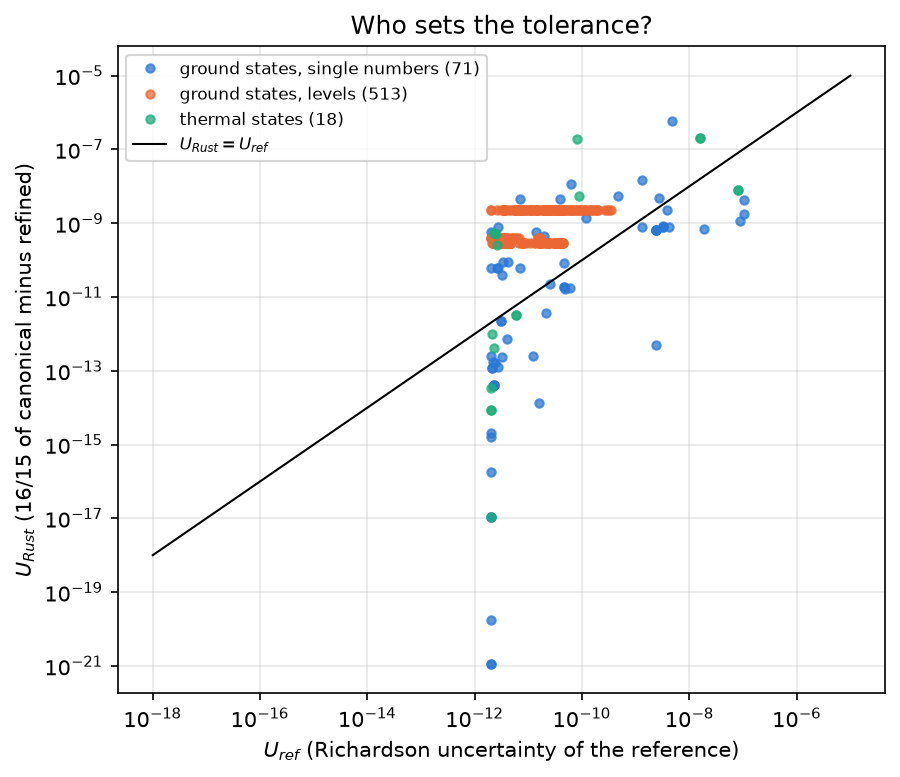

Figure 16a.6 saved as Revision/textbook/figures/16a_6_uncertainty_budget.png
547 of 602 drawn comparisons have U_Rust > U_ref
PASS the uncertainty budget has more than 500 comparisons


In [21]:
groups = {"ground states, single numbers": [], "ground states, levels": [],
          "thermal states": []}
for r in ROWS:
    if r[0] == "ground_profiles" or r[4] <= 0.0 or r[5] <= 0.0:
        continue  # profile points are drawn elsewhere; a zero U has no logarithm
    if r[1].split()[0] in THERMAL_IDS:
        groups["thermal states"].append(r)
    elif r[0] == "ground_eigenvalues":
        groups["ground states, levels"].append(r)
    else:
        groups["ground states, single numbers"].append(r)
fig, ax = plt.subplots(figsize=(6.6, 5.6))
for colour, (label, rows) in zip(PALETTE, groups.items()):
    ax.loglog([r[4] for r in rows], [r[5] for r in rows], "o", color=colour, ms=4,
              alpha=0.75, label=f"{label} ({len(rows)})")
span = np.array([1e-18, 1e-5])
ax.loglog(span, span, "k-", lw=1.0, label="$U_{Rust} = U_{ref}$")
ax.set_xlabel("$U_{ref}$ (Richardson uncertainty of the reference)")
ax.set_ylabel("$U_{Rust}$ (16/15 of canonical minus refined)")
ax.set_title("Who sets the tolerance?")
ax.legend(fontsize=8)
above = sum(1 for rows in groups.values() for r in rows if r[5] > r[4])
total = sum(len(rows) for rows in groups.values())
save_figure(fig, "uncertainty_budget",
            "The two uncertainties that make the tolerance, for every comparison of "
            "single numbers and of levels in the five states of the subset: the "
            "Richardson uncertainty $U_{ref}$ of the reference solver (horizontal) "
            "and the measured uncertainty $U_{Rust}$ of the Rust solver (vertical), "
            "both logarithmic and in the units of the quantity. Points above the "
            "diagonal are dominated by the Rust uncertainty, points below it by the "
            f"reference; {above} of the {total} points lie above it. Comparisons in "
            "which one uncertainty is exactly zero are left out.")
say(f"{above} of {total} drawn comparisons have U_Rust > U_ref")
check(total > 500, "the uncertainty budget has more than 500 comparisons")

The last figure gathers all 5140 comparisons of the subset by class. Each dot is one
comparison, spread a little sideways so that dots do not hide each other; ratios
below one millionth (including exact agreement) are drawn at $10^{-6}$. The orange
diamond marks the largest ratio of each class.

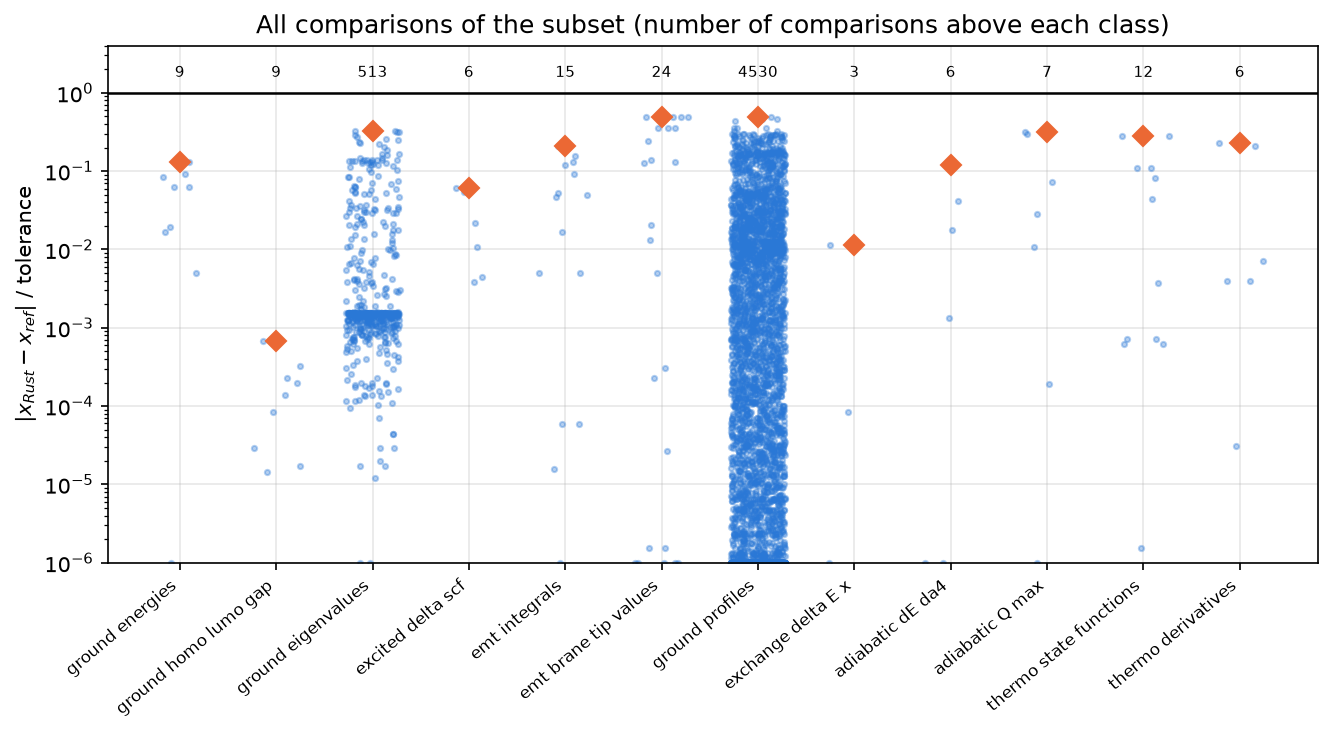

Figure 16a.7 saved as Revision/textbook/figures/16a_7_ratios_by_class.png
  ground_energies          largest ratio 0.1315
  ground_homo_lumo_gap     largest ratio 0.0007
  ground_eigenvalues       largest ratio 0.3244
  excited_delta_scf        largest ratio 0.0610
  emt_integrals            largest ratio 0.2088
  emt_brane_tip_values     largest ratio 0.4952
  ground_profiles          largest ratio 0.4952
  exchange_delta_E_x       largest ratio 0.0115
  adiabatic_dE_da4         largest ratio 0.1216
  adiabatic_Q_max          largest ratio 0.3142
  thermo_state_functions   largest ratio 0.2843
  thermo_derivatives       largest ratio 0.2257
the largest ratio of the subset: 0.4952 (N8_lamm2_a00 rho_tip)
PASS no comparison uses half of its tolerance; the largest is rho at the tip


In [22]:
classes = ["ground_energies", "ground_homo_lumo_gap", "ground_eigenvalues",
           "excited_delta_scf", "emt_integrals", "emt_brane_tip_values",
           "ground_profiles", "exchange_delta_E_x", "adiabatic_dE_da4",
           "adiabatic_Q_max", "thermo_state_functions", "thermo_derivatives"]
rng = np.random.default_rng(12345)  # fixed seed: the same picture in every run
fig, ax = plt.subplots(figsize=(9.0, 5.0))
worst_by_class = {}
for i, cls in enumerate(classes):
    ratios = np.array([r[8] for r in ROWS if r[0] == cls])
    jitter = rng.uniform(-0.28, 0.28, size=len(ratios))
    ax.semilogy(i + jitter, np.maximum(ratios, 1e-6), "o", color=PALETTE[0], ms=2.5,
                alpha=0.35)
    worst_by_class[cls] = float(ratios.max())
    ax.semilogy([i], [max(ratios.max(), 1e-6)], "D", color=PALETTE[1], ms=7)
    ax.text(i, 1.6, f"{len(ratios)}", ha="center", fontsize=7)
ax.axhline(1.0, color="k", lw=1.2)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([c.replace("_", " ") for c in classes], rotation=40, ha="right",
                   fontsize=8)
ax.set_ylim(1e-6, 4.0)
ax.set_ylabel("$|x_{Rust} - x_{ref}|$ / tolerance")
ax.set_title("All comparisons of the subset (number of comparisons above each class)")
fig.tight_layout()
top_class = max(worst_by_class, key=worst_by_class.get)
save_figure(fig, "ratios_by_class",
            f"All {len(ROWS)} comparisons of the five states of the subset, grouped "
            "by the class of the cross-check: each dot is one ratio of the difference "
            "of the two solvers to the tolerance (logarithmic; ratios below "
            "$10^{-6}$ drawn at $10^{-6}$), the diamond is the largest ratio of the "
            "class, the number above a class counts its comparisons, and the black "
            "line is the tolerance. Every dot lies below it; the largest ratio, "
            f"{worst_by_class[top_class]:.3f}, belongs to the tip value of the energy "
            "density of N8_lamm2_a00.")
for cls in classes:
    say(f"  {cls:24s} largest ratio {worst_by_class[cls]:.4f}")
top_row = max(ROWS, key=lambda r: r[8])  # the comparison with the largest ratio
say(f"the largest ratio of the subset: {top_row[8]:.4f} ({top_row[1]})")
check(max(worst_by_class.values()) < 0.5
      and top_row[1] == "N8_lamm2_a00 rho_tip",
      "no comparison uses half of its tolerance; the largest is rho at the tip")

## 18. The last check

The next cell confirms that every figure of this notebook was written, and prints
the number of checks that passed.

In [23]:
figure_files = [f"{FIGURE_FOLDER}/16a_{k}_{name}.png" for k, name in enumerate(
    ["grid_convergence", "uncertainty_validated", "eigenvalue_ratios",
     "level_agreement", "profile_agreement", "uncertainty_budget",
     "ratios_by_class"], start=1)]
check(all(output_file(f).is_file() for f in figure_files),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 51 CHECKS PASSED (notebook 16a)


## 19. What this notebook showed

- The reference program, run again here on five states and on the fourth grid,
  reproduces the committed reference results: every number within one part in a
  billion (on the computer that built the book, byte for byte).
- Its grids converge like $h^2$: the differences shrink by a factor 4 from grid to
  grid, for $E_{KS}$ and for every level; two Richardson steps remove the $h^2$ and
  $h^4$ errors, and $U$ measures what is left. On a fourth grid every three-grid
  value of N136_lamp2_a20 moves by less than its $U$ (at most 0.787 of it, at the
  tip), so $U$ is a safe estimate of the remaining error.
- The Rust solver, run again with its canonical numerics, reproduces its committed
  results, and its refined run reproduces the recorded canonical-minus-refined
  differences, from which $U_{Rust} = \tfrac{16}{15}|canonical - refined|$.
- With the tolerance rule $|x_{Rust} - x_{ref}| \le 3(U_{ref} + U_{Rust}) +
  10^{-12}\,$scale, fixed before the comparison, all 5140 comparisons of the subset
  pass; our tolerances and ratios equal the 97 rows of the committed table, and the
  worst cases of six classes of the full cross-check (largest ratio 0.495) are
  reproduced exactly.
- What this does NOT show: both solvers implement the same functional, the same
  ASSUMED $Z_2$ brane, the same tip cutoff and the same filling CONVENTION, and both
  compute instantaneous (adiabatic) states along a PRESCRIBED BACKGROUND history. An
  error in those common inputs cannot be detected by comparing the two programs. The
  cross-check tests the numerics, not the physics model.